
   TRAINING MODELS FOR: DL
Loading and preparing data from 'DL_fill.csv'...
  Imputing 159670 missing feature values using 'mean' strategy...
  ✅ Prepared 72478 usable data rows.
  Training Longitude model for DL...

--- Creating and Saving ONNX pipeline for DL Lon ---
  ✅ ONNX pipeline successfully saved to: trained_silo_models_v1\pipeline_lon_DL.onnx
  Training Latitude model for DL...

--- Creating and Saving ONNX pipeline for DL Lat ---
  ✅ ONNX pipeline successfully saved to: trained_silo_models_v1\pipeline_lat_DL.onnx

--- Evaluating DL & Plotting CDF ---
  Median Error: 0.18m
  Mean Error:   2.03m


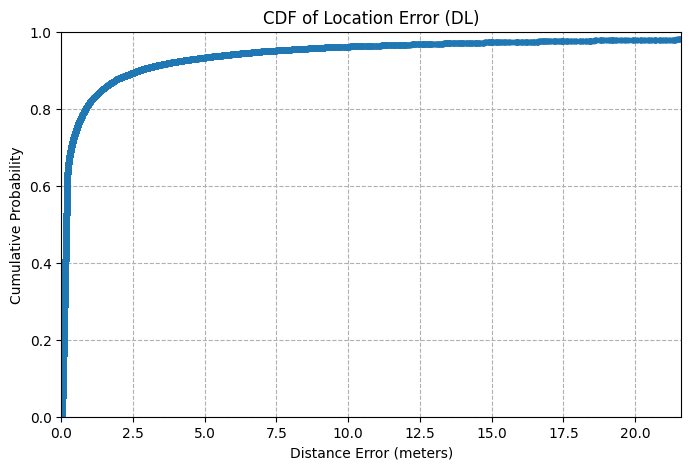


   TRAINING MODELS FOR: UL
Loading and preparing data from 'UL_fill.csv'...
  Imputing 129797 missing feature values using 'mean' strategy...
  ✅ Prepared 72478 usable data rows.
  Training Longitude model for UL...

--- Creating and Saving ONNX pipeline for UL Lon ---
  ✅ ONNX pipeline successfully saved to: trained_silo_models_v1\pipeline_lon_UL.onnx
  Training Latitude model for UL...

--- Creating and Saving ONNX pipeline for UL Lat ---
  ✅ ONNX pipeline successfully saved to: trained_silo_models_v1\pipeline_lat_UL.onnx

--- Evaluating UL & Plotting CDF ---
  Median Error: 0.17m
  Mean Error:   2.07m


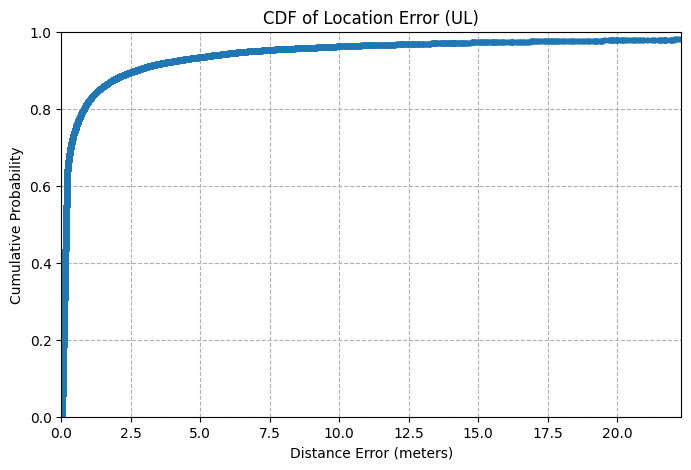


   TRAINING MODELS FOR: SCANNER
Loading and preparing data from 'Scanner_fill.csv'...
  ✅ Prepared 22392 usable data rows.
  Training Longitude model for Scanner...

--- Creating and Saving ONNX pipeline for Scanner Lon ---
  ✅ ONNX pipeline successfully saved to: trained_silo_models_v1\pipeline_lon_Scanner.onnx
  Training Latitude model for Scanner...

--- Creating and Saving ONNX pipeline for Scanner Lat ---
  ✅ ONNX pipeline successfully saved to: trained_silo_models_v1\pipeline_lat_Scanner.onnx

--- Evaluating Scanner & Plotting CDF ---
  Median Error: 0.87m
  Mean Error:   3.19m


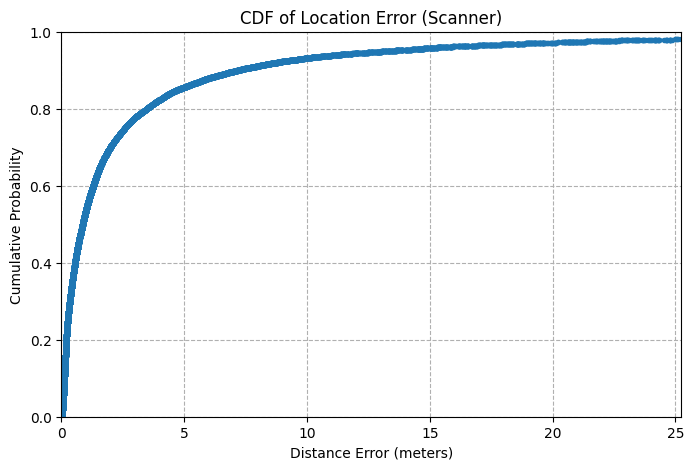


   DEMONSTRATING FUSION
Calculating Fusion Weights (1 / Median Error):
  - DL: 5.6901 (from 0.18m error)
  - UL: 5.7596 (from 0.17m error)
  - Scanner: 1.1501 (from 0.87m error)

Loading a sample (10 rows) from each data source for demonstration...
Loading and preparing data from 'DL_fill.csv'...
  Imputing 159670 missing feature values using 'mean' strategy...
  ✅ Prepared 72478 usable data rows.
Loading and preparing data from 'UL_fill.csv'...
  Imputing 129797 missing feature values using 'mean' strategy...
  ✅ Prepared 72478 usable data rows.
Loading and preparing data from 'Scanner_fill.csv'...
  ✅ Prepared 22392 usable data rows.

--- Predictions on Sample Data (Index-by-Index) ---

--- Sample Index 0 ---
          DL: Actual=(29.02949, 41.10723) -> Predicted=(29.02949, 41.10723)
          UL: Actual=(29.02949, 41.10723) -> Predicted=(29.02949, 41.10723)
     Scanner: Actual=(29.02949, 41.10723) -> Predicted=(29.02949, 41.10723)
   ==> FUSED: Final Prediction = (29.02949, 41.107

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import skl2onnx
from skl2onnx.common.data_types import FloatTensorType
import onnxruntime as rt
from math import radians, sin, cos, sqrt, atan2, asin
import matplotlib.pyplot as plt
import joblib
import os

# Use scikit-learn's Regressor for ONNX compatibility
from sklearn.ensemble import RandomForestRegressor as SklearnRandomForestRegressor

# --- 1. CORE CONFIGURATION ---
# Define all data sources, their features, and model paths here.
# ! --- IMPORTANT: UPDATE THIS SECTION --- !#
MODEL_DIR = "trained_silo_models_v1"
TARGET_COLS = ['Longitude', 'Latitude']

DATA_SOURCES_CONFIG = {
    'DL': {
        'filepath': 'DL_fill.csv',
        'feature_cols': [ # Features specific to or available in the DL dataset
            'NR_UE_PCI_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0',
            'NR_UE_Pathloss_DL_0', 'NR_UE_Nbr_RSRQ_0', 'NR_UE_Nbr_RSRP_0',
            'NR_UE_Nbr_PCI_0',
            #   'NR_UE_Modulation_Avg_DL_0', 'NR_UE_Timing_Advance'
        ],
        'model_lon_path': os.path.join(MODEL_DIR, 'rf_lon_DL.joblib'),
        'model_lat_path': os.path.join(MODEL_DIR, 'rf_lat_DL.joblib'),
        'scaler_path': os.path.join(MODEL_DIR, 'scaler_DL.joblib'),
        'onnx_lon_path': os.path.join(MODEL_DIR, 'pipeline_lon_DL.onnx'),
        'onnx_lat_path': os.path.join(MODEL_DIR, 'pipeline_lat_DL.onnx'),
    },
    'UL': {
        'filepath': 'UL_fill.csv',
        'feature_cols': [ # Features specific to or available in the UL dataset
            'NR_UE_PCI_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0',
            'NR_UE_Pathloss_DL_0', 'NR_UE_Nbr_RSRQ_0', 'NR_UE_Nbr_RSRP_0',
            'NR_UE_Nbr_PCI_0', 
            # 'NR_UE_Modulation_Avg_UL_0', 'NR_UE_Timing_Advance',
            # 'NR_UE_Power_Tx_PUSCH_0'
        ],
        'model_lon_path': os.path.join(MODEL_DIR, 'rf_lon_UL.joblib'),
        'model_lat_path': os.path.join(MODEL_DIR, 'rf_lat_UL.joblib'),
        'scaler_path': os.path.join(MODEL_DIR, 'scaler_UL.joblib'),
        'onnx_lon_path': os.path.join(MODEL_DIR, 'pipeline_lon_UL.onnx'),
        'onnx_lat_path': os.path.join(MODEL_DIR, 'pipeline_lat_UL.onnx'),
    },
    'Scanner': {
        'filepath': 'Scanner_fill.csv',
        'feature_cols': [ 
            'NR_Scan_PCI_SortedBy_RSRP_0',
'NR_Scan_PCI_SortedBy_RSRP_1',
'NR_Scan_PCI_SortedBy_RSRP_2',
'NR_Scan_PCI_SortedBy_RSRP_3',
# 'NR_Scan_PCI_SortedBy_RSRP_4',
# 'NR_Scan_PCI_SortedBy_RSRP_5',
# 'NR_Scan_PCI_SortedBy_RSRP_6',


'NR_Scan_SSB_RSRP_SortedBy_RSRP_0',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_1',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_2',
'NR_Scan_SSB_RSRP_SortedBy_RSRP_3',
# 'NR_Scan_SSB_RSRP_SortedBy_RSRP_4',
# 'NR_Scan_SSB_RSRP_SortedBy_RSRP_5',
# 'NR_Scan_SSB_RSRP_SortedBy_RSRP_6',

'NR_Scan_SSB_RSRQ_SortedBy_RSRP_0',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_1',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_2',
'NR_Scan_SSB_RSRQ_SortedBy_RSRP_3',
# 'NR_Scan_SSB_RSRQ_SortedBy_RSRP_4',
# 'NR_Scan_SSB_RSRQ_SortedBy_RSRP_5',
# 'NR_Scan_SSB_RSRQ_SortedBy_RSRP_6',

'NR_Scan_SSB_SINR_SortedBy_RSRP_0',
'NR_Scan_SSB_SINR_SortedBy_RSRP_1',
'NR_Scan_SSB_SINR_SortedBy_RSRP_2',
'NR_Scan_SSB_SINR_SortedBy_RSRP_3'
# 'NR_Scan_SSB_SINR_SortedBy_RSRP_4',
# 'NR_Scan_SSB_SINR_SortedBy_RSRP_5',
# 'NR_Scan_SSB_SINR_SortedBy_RSRP_6',

        ],
        'model_lon_path': os.path.join(MODEL_DIR, 'rf_lon_Scanner.joblib'),
        'model_lat_path': os.path.join(MODEL_DIR, 'rf_lat_Scanner.joblib'),
        'scaler_path': os.path.join(MODEL_DIR, 'scaler_Scanner.joblib'),
        'onnx_lon_path': os.path.join(MODEL_DIR, 'pipeline_lon_Scanner.onnx'),
        'onnx_lat_path': os.path.join(MODEL_DIR, 'pipeline_lat_Scanner.onnx'),
    }
}


def haversine(lat1, lon1, lat2, lon2):
    if any(pd.isna([lat1, lon1, lat2, lon2])): return np.nan
    lon1, lat1, lon2, lat2 = map(radians, [float(lon1), float(lat1), float(lon2), float(lat2)])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * asin(sqrt(a))
    r = 6371
    return c * r * 1000

def save_pipeline_as_onnx(model, scaler, feature_names, onnx_model_path, model_type=""):
    """Creates a pipeline and saves it to ONNX format."""
    print(f"\n--- Creating and Saving ONNX pipeline for {model_type} ---")
    pipeline = Pipeline([
        ('scaler', scaler),
        ('regressor', model)
    ])
    initial_type = [('float_input', FloatTensorType([None, len(feature_names)]))]
    try:
        onx = skl2onnx.to_onnx(pipeline, initial_types=initial_type)
        with open(onnx_model_path, "wb") as f:
            f.write(onx.SerializeToString())
        print(f"  ✅ ONNX pipeline successfully saved to: {onnx_model_path}")
    except Exception as e:
        print(f"  ❌ Error during ONNX conversion for {model_type}: {e}")

def load_and_prepare_single_source_data(filepath, feature_cols, target_cols, impute_strategy='mean'):
    """
    Loads and prepares data from a single CSV file for one specific model silo.
    Includes validation to ensure all expected columns are present.
    """
    print(f"Loading and preparing data from '{filepath}'...")
    try:
        # Read only the columns we might need to be more memory efficient
        all_expected_cols = feature_cols + target_cols
        df = pd.read_csv(filepath, usecols=lambda c: c in all_expected_cols, low_memory=False)
    except FileNotFoundError:
        print(f"  ❌ ERROR: File not found: {filepath}. Skipping this data source.")
        return None, None, None
    except ValueError as e:
        print(f"  ❌ ERROR: A required column might be missing or there's an issue with the file {filepath}. Details: {e}. Skipping.")
        return None, None, None

    # --- NEW: VALIDATION BLOCK ---
    # Check if all expected feature columns were actually found in the file
    missing_features = [col for col in feature_cols if col not in df.columns]
    if missing_features:
        print(f"  ❌ ERROR: The following feature columns defined in the config were NOT found in '{filepath}':")
        for col in missing_features:
            print(f"    - {col}")
        print("  Please correct the 'feature_cols' list in DATA_SOURCES_CONFIG. Skipping this source.")
        return None, None, None
    # --- END: VALIDATION BLOCK ---

    # Standard cleaning
    df_subset = df[feature_cols + target_cols].copy()
    for col in df_subset.columns:
        if df_subset[col].dtype == 'object':
            df_subset[col] = df_subset[col].replace(['-', 'NA', 'N/A', '', ' ', 'null', 'NULL'], np.nan, regex=False)
        df_subset[col] = pd.to_numeric(df_subset[col], errors='coerce')

    # Drop rows where target values are missing
    df_cleaned = df_subset.dropna(subset=target_cols)
    if df_cleaned.empty:
        print("  ❌ ERROR: No rows with valid targets found. Skipping.")
        return None, None, None

    X = df_cleaned[feature_cols].copy()
    y_lon = df_cleaned[target_cols[0]]
    y_lat = df_cleaned[target_cols[1]]

    # Impute missing feature values
    if X.isna().sum().sum() > 0:
        print(f"  Imputing {X.isna().sum().sum()} missing feature values using '{impute_strategy}' strategy...")
        imputer = SimpleImputer(strategy=impute_strategy)
        X_imputed = imputer.fit_transform(X)
        X = pd.DataFrame(X_imputed, columns=feature_cols, index=X.index)

    print(f"  ✅ Prepared {len(X)} usable data rows.")
    return X, y_lon, y_lat
def train_model(X_train, y_train, n_estimators=100, random_state=42):
    """Trains a single RandomForestRegressor model."""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    y_train_np = y_train.values.astype(np.float32)

    model = SklearnRandomForestRegressor(
        n_estimators=n_estimators, random_state=random_state, n_jobs=-1
    )
    model.fit(X_train_scaled, y_train_np)
    return model, scaler

def evaluate_and_plot_cdf_rf(X_eval, y_lon_actual, y_lat_actual, model_lon, model_lat, scaler, model_type_name):
    """Evaluates models and returns the median haversine error."""
    print(f"\n--- Evaluating {model_type_name} & Plotting CDF ---")
    if X_eval is None or X_eval.empty:
        print("No data for evaluation.")
        return float('inf') # Return a huge error if no data

    X_eval_scaled = scaler.transform(X_eval)
    y_lon_pred = model_lon.predict(X_eval_scaled)
    y_lat_pred = model_lat.predict(X_eval_scaled)

    distances = [
        haversine(y_lat_actual.iloc[i], y_lon_actual.iloc[i], y_lat_pred[i], y_lon_pred[i])
        for i in range(len(y_lon_actual))
    ]
    distances = [d for d in distances if not pd.isna(d)]

    if not distances:
        print("  No valid distances calculated for CDF.")
        return float('inf')

    median_error = np.median(distances)
    print(f"  Median Error: {median_error:.2f}m")
    print(f"  Mean Error:   {np.mean(distances):.2f}m")

    # Plotting logic
    sorted_distances = np.sort(distances)
    cum_prob = np.arange(1, len(sorted_distances) + 1) / len(sorted_distances)
    plt.figure(figsize=(8, 5))
    plt.plot(sorted_distances, cum_prob, marker='.', linestyle='-')
    plt.title(f'CDF of Location Error ({model_type_name})')
    plt.xlabel('Distance Error (meters)')
    plt.ylabel('Cumulative Probability')
    plt.grid(True, which='both', linestyle='--')
    plt.xlim(left=0, right=np.percentile(sorted_distances, 98))
    plt.ylim(0, 1)
    plt.show()

    return median_error


# --- 3. MAIN EXECUTION SCRIPT ---
if __name__ == "__main__":
    if not os.path.exists(MODEL_DIR):
        os.makedirs(MODEL_DIR)

    trained_artifacts = {}

    # --- PART A: Train a Model for Each Data Source ---
    for source_name, config in DATA_SOURCES_CONFIG.items():
        print(f"\n{'='*25}\n   TRAINING MODELS FOR: {source_name.upper()}\n{'='*25}")

        # 1. Load Data
        X, y_lon, y_lat = load_and_prepare_single_source_data(
            config['filepath'], config['feature_cols'], TARGET_COLS
        )

        if X is None:
            continue

        # 2. Train Longitude and Latitude models
        print(f"  Training Longitude model for {source_name}...")
        model_lon, scaler_lon = train_model(X, y_lon)
        joblib.dump(model_lon, config['model_lon_path'])
        joblib.dump(scaler_lon, config['scaler_path']) # Save one scaler per source
        save_pipeline_as_onnx(model_lon, scaler_lon, config['feature_cols'], config['onnx_lon_path'], f"{source_name} Lon")


        print(f"  Training Latitude model for {source_name}...")
        model_lat, scaler_lat = train_model(X, y_lat) # Retrain scaler for lat just in case, though it should be identical
        joblib.dump(model_lat, config['model_lat_path'])
        save_pipeline_as_onnx(model_lat, scaler_lat, config['feature_cols'], config['onnx_lat_path'], f"{source_name} Lat")


        # 3. Evaluate the trained models and store the error
        median_error = evaluate_and_plot_cdf_rf(
            X, y_lon, y_lat, model_lon, model_lat, scaler_lon, source_name
        )

        # 4. Store models, scaler, and error for the fusion step
        trained_artifacts[source_name] = {
            'model_lon': model_lon,
            'model_lat': model_lat,
            'scaler': scaler_lon, # We only need one scaler
            'features': config['feature_cols'],
            'error': median_error
        }

# --- PART B: Demonstrate Predictions and Simple Fusion ---
print(f"\n{'='*25}\n   DEMONSTRATING FUSION\n{'='*25}")

if not trained_artifacts:
    print("No models were trained, cannot demonstrate fusion. Exiting.")
else:
    # 1. Calculate weights for each model (inversely proportional to median error)
    weights = {}
    print("Calculating Fusion Weights (1 / Median Error):")
    for source_name, data in trained_artifacts.items():
        error = data.get('error', float('inf'))
        # Avoid division by zero. If error is 0 or inf, give it a tiny weight (effectively 0).
        if error > 0 and np.isfinite(error):
            weights[source_name] = 1 / error
        else:
            weights[source_name] = 0
        print(f"  - {source_name}: {weights[source_name]:.4f} (from {error:.2f}m error)")

    # 2. --- NEW: Create a dictionary of sample data, one for each source ---
    sample_data_per_source = {}
    print("\nLoading a sample (10 rows) from each data source for demonstration...")
    for source_name, config in DATA_SOURCES_CONFIG.items():
        # Check if the model was actually trained before trying to load its data
        if source_name in trained_artifacts:
            sample_X, sample_y_lon, sample_y_lat = load_and_prepare_single_source_data(
                config['filepath'], config['feature_cols'], TARGET_COLS
            )
            if sample_X is not None:
                sample_data_per_source[source_name] = {
                    'X': sample_X.head(10),
                    'y_lon': sample_y_lon.head(10),
                    'y_lat': sample_y_lat.head(10)
                }

    if not sample_data_per_source:
        print("Could not load any sample data. Cannot demonstrate fusion.")
    else:
        # 3. Loop through a few sample indices and predict with all models
        print("\n--- Predictions on Sample Data (Index-by-Index) ---")
        
        # We will demonstrate on 5 samples
        for i in range(5):
            print(f"\n--- Sample Index {i} ---")
            
            fused_lon, fused_lat, total_weight = 0.0, 0.0, 0.0
            
            # Get prediction from each model silo for this index i
            for source_name, data in trained_artifacts.items():
                
                # Check if we have sample data for this source
                if source_name not in sample_data_per_source:
                    print(f"  {source_name:>10s}: No sample data loaded, skipping.")
                    continue

                # Get the correct sample data for this specific model
                source_samples = sample_data_per_source[source_name]
                sample_row_X = source_samples['X'].iloc[[i]] # Use [[i]] to keep it as a DataFrame
                actual_lon = source_samples['y_lon'].iloc[i]
                actual_lat = source_samples['y_lat'].iloc[i]
                
                # Get the correct trained model artifacts
                model_lon = data['model_lon']
                model_lat = data['model_lat']
                scaler = data['scaler']

                # The scaler expects a DataFrame with feature names, so we don't use .values
                input_scaled = scaler.transform(sample_row_X)
                
                pred_lon = model_lon.predict(input_scaled)[0]
                pred_lat = model_lat.predict(input_scaled)[0]

                print(f"  {source_name:>10s}: Actual=({actual_lon:.5f}, {actual_lat:.5f}) -> Predicted=({pred_lon:.5f}, {pred_lat:.5f})")
                
                # Add to the weighted average calculation
                w = weights.get(source_name, 0)
                if w > 0:
                    fused_lon += pred_lon * w
                    fused_lat += pred_lat * w
                    total_weight += w
            
            # Finalize fusion calculation for this sample index
            if total_weight > 0:
                fused_lon /= total_weight
                fused_lat /= total_weight
                print(f"  {'==> FUSED':>10s}: Final Prediction = ({fused_lon:.5f}, {fused_lat:.5f})")
            else: # Fallback if all weights are zero
                print(f"  {'==> FUSED':>10s}: Could not compute fused prediction (total weight is zero).")

cuML RandomForestRegressor not found. Using scikit-learn's RandomForestRegressor (CPU-based).
=== PART 1: SINGLE-SNAPSHOT FINGERPRINTING WITH RandomForest (sklearn) ===

Inspecting headers in UL_fill.csv for potential features...

Inspecting headers in DL_fill.csv for potential features...

Common canonical features for processing: ['Modulation_Avg', 'NR_UE_Nbr_PCI_0', 'NR_UE_Nbr_RSRP_0', 'NR_UE_Nbr_RSRQ_0', 'NR_UE_PCI_0', 'NR_UE_Power_Tx_PUSCH_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0', 'NR_UE_Timing_Advance', 'Pathloss_Estimate']
Processing UL_fill.csv with common feature set...
  Imputing for 'UL_fill.csv' on 10 features using 'mean'...
    NaN counts AFTER imputation for 'UL_fill.csv': 72478
  Added 72478 rows from 'UL_fill.csv'.
Processing DL_fill.csv with common feature set...
  Imputing for 'DL_fill.csv' on 10 features using 'mean'...
    NaN counts AFTER imputation for 'DL_fill.csv': 72478
  Added 72478 rows from 'DL_fill.csv'.
  Combined dataset had all-NaN columns: ['

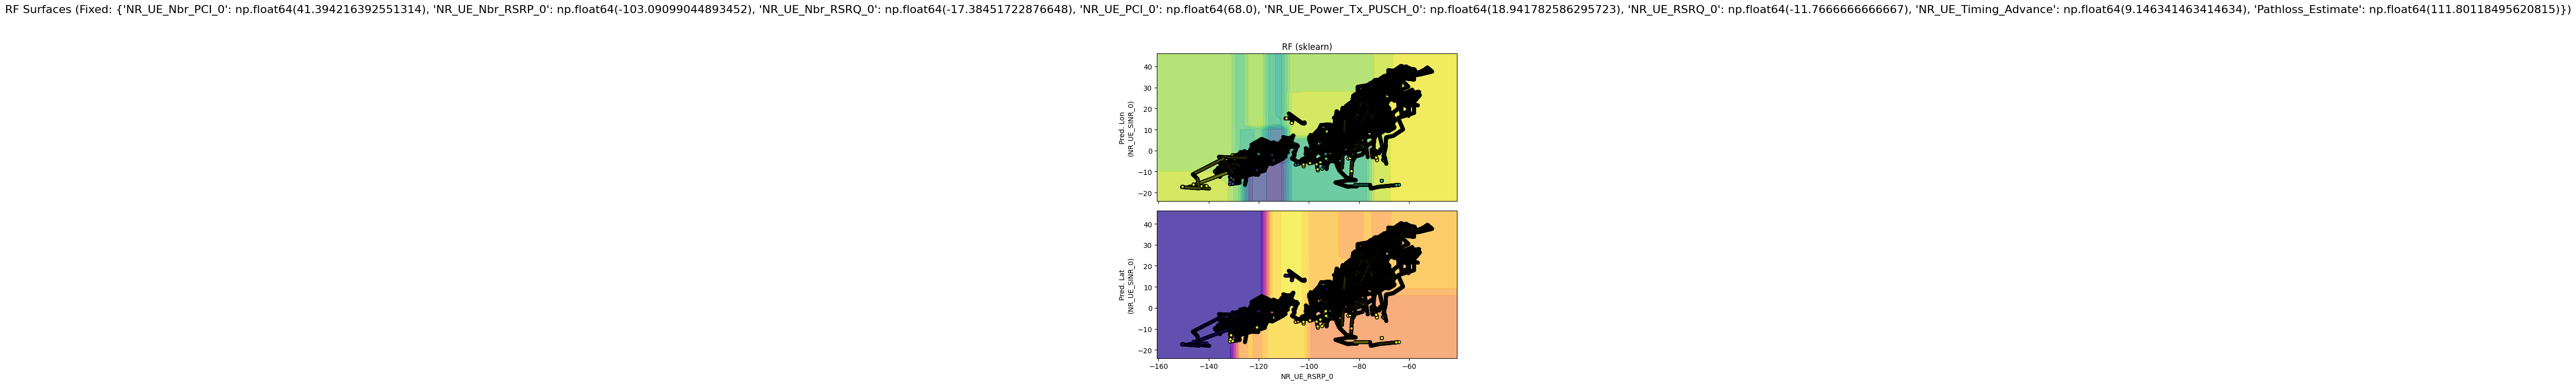

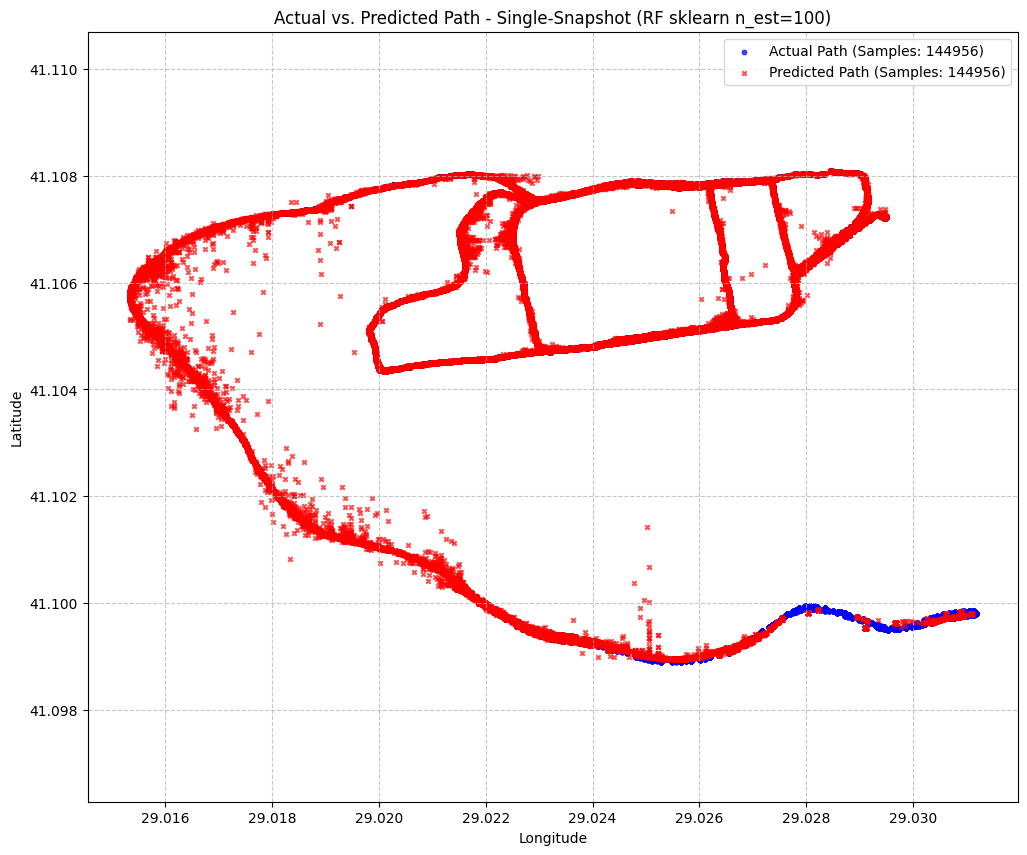


--- Evaluating Single-Snapshot (RF n_est=100, Backend: sklearn) & CDF ---


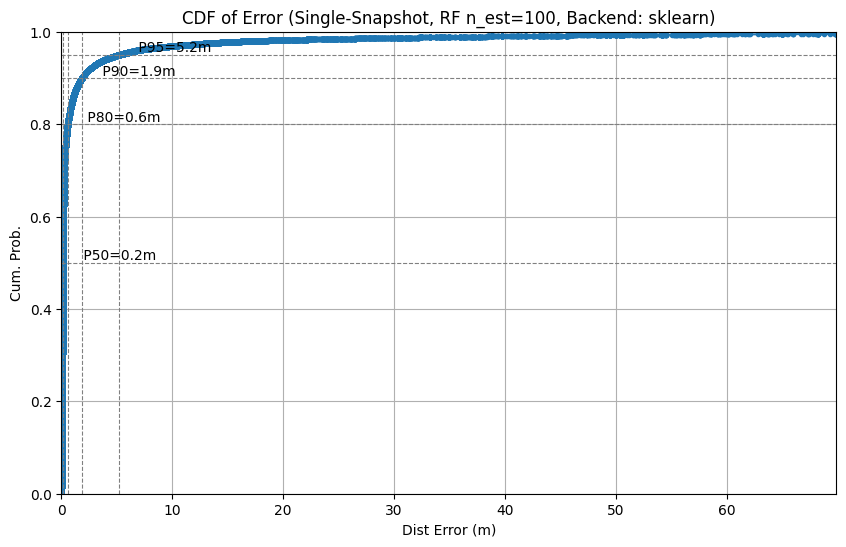

  Mean error: 1.75m, Median: 0.16m


=== PART 2: WINDOWED MVF WITH RandomForest (sklearn) ===

Creating Windowed MVF features with T=5 using 9 base radio features...
  Generated 138900 windowed MVF samples (each with 46 features).
  Model & scaler loaded:trained_models_rf_multi_file_final_v2\rf_mvf_t5_lon.joblib,trained_models_rf_multi_file_final_v2\scaler_mvf_t5.joblib
  Model & scaler loaded:trained_models_rf_multi_file_final_v2\rf_mvf_t5_lat.joblib,trained_models_rf_multi_file_final_v2\scaler_mvf_t5.joblib
  Scaler feature count mismatch for MVF. Retraining MVF RF.
  Training windowed MVF RF for Longitude...
  Feature scaler saved: trained_models_rf_multi_file_final_v2\scaler_mvf_t5.joblib
  Training RF Lon (MVF) (n_est=100). Backend: sklearn
    Trained with sklearn RF (CPU).
  Model saved:trained_models_rf_multi_file_final_v2\rf_mvf_t5_lon.joblib, Scaler:trained_models_rf_multi_file_final_v2\scaler_mvf_t5.joblib

--- Creating and Saving ONNX pipeline for MVF Lon ---
  ✅ ONNX pipel

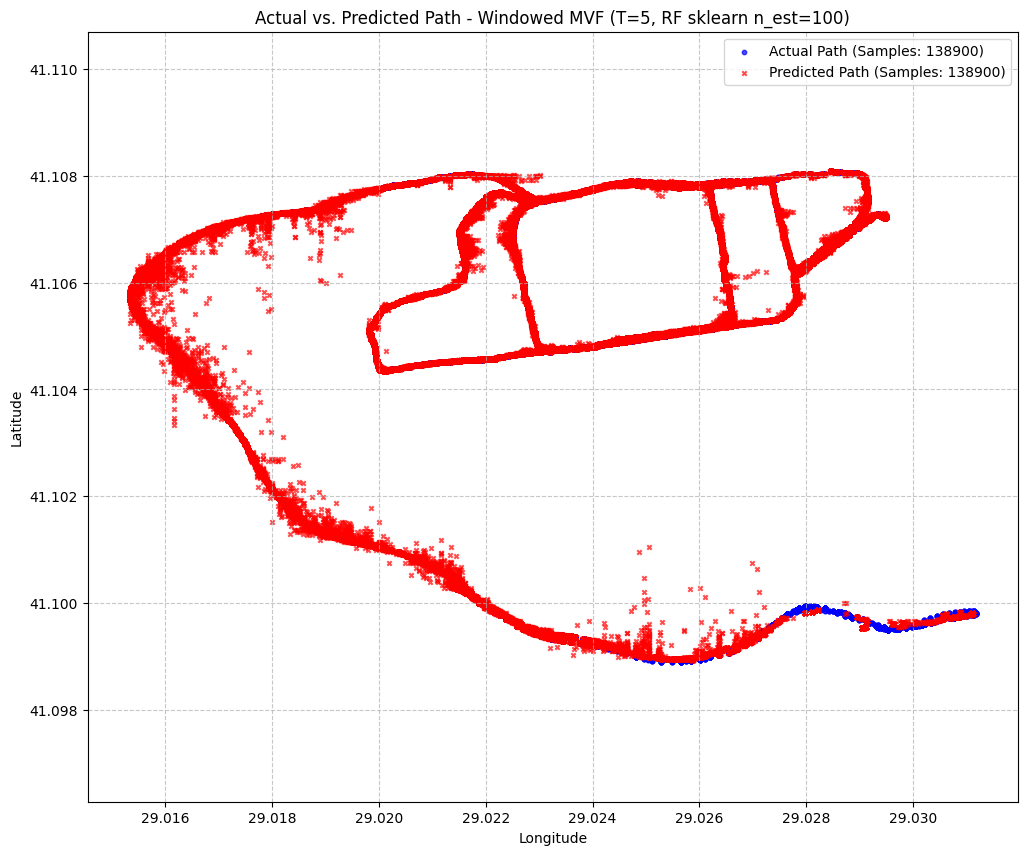


--- Evaluating Windowed MVF (T=5) (RF n_est=100, Backend: sklearn) & CDF ---


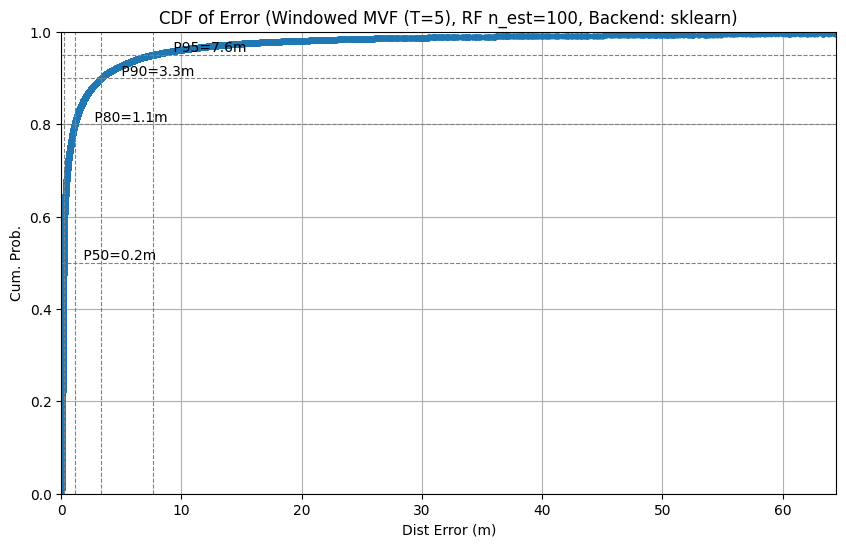

  Mean error: 2.04m, Median: 0.19m

--- Predict Location using Windowed MVF RandomForest Model (T=5) ---
Please enter values for prediction (using canonical feature names based on loaded data):
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.
Invalid input.


KeyboardInterrupt: Interrupted by user

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
# --- New/Modified Imports for ONNX ---
from sklearn.pipeline import Pipeline
import skl2onnx
from skl2onnx.common.data_types import FloatTensorType
import onnxruntime as rt
# --- End ONNX Imports ---
from math import radians, sin, cos, sqrt, atan2, asin
import matplotlib.pyplot as plt
import joblib
import os

# Try to import cuML RandomForestRegressor, fallback to scikit-learn
try:
    from cuml.ensemble import RandomForestRegressor as cuMLRandomForestRegressor
    import cupy
    print("cuML RandomForestRegressor found. Will attempt to use GPU.")
    RF_BACKEND_DEFAULT = "cuml"
except ImportError:
    from sklearn.ensemble import RandomForestRegressor as SklearnRandomForestRegressor
    print("cuML RandomForestRegressor not found. Using scikit-learn's RandomForestRegressor (CPU-based).")
    RF_BACKEND_DEFAULT = "sklearn"
    cupy = None

# --- Configuration ---
FILE_PATH_INPUTS = ['UL_fill.csv', 'DL_fill.csv']

FEATURE_MAPPING = {
    'NR_UE_PCI_0': ['NR_UE_PCI_0'],
    'NR_UE_RSRP_0': ['NR_UE_RSRP_0'],
    'NR_UE_RSRQ_0': ['NR_UE_RSRQ_0'],
    'NR_UE_SINR_0': ['NR_UE_SINR_0'],
    'Pathloss_Estimate': ['NR_UE_Pathloss_DL_0', 'NR_UE_Pathloss_UL_0'],
    'NR_UE_Nbr_RSRQ_0': ['NR_UE_Nbr_RSRQ_0'],
    'NR_UE_Nbr_RSRP_0': ['NR_UE_Nbr_RSRP_0'],
    'NR_UE_Nbr_PCI_0': ['NR_UE_Nbr_PCI_0'],
    'Modulation_Avg': ['NR_UE_Modulation_Avg_DL_0', 'NR_UE_Modulation_Avg_UL_0'],
    'NR_UE_Timing_Advance': ['NR_UE_Timing_Advance'],
    'NR_UE_Power_Tx_PUSCH_0': ['NR_UE_Power_Tx_PUSCH_0']
}
CANONICAL_FEATURE_COLS = list(FEATURE_MAPPING.keys())
TARGET_COLS_LIST = ['Longitude', 'Latitude']
PCI_COL_MVF = 'NR_UE_PCI_0'

RF_N_ESTIMATORS = 100
RF_MAX_DEPTH = None
RF_MIN_SAMPLES_SPLIT = 2
RF_MIN_SAMPLES_LEAF = 1
RF_RANDOM_STATE = 42
IMPUTE_STRATEGY = 'mean'
WINDOW_SIZE_T = 5

MODEL_DIR = "trained_models_rf_multi_file_final_v2" # New directory
RF_SINGLE_MODEL_LON_PATH = os.path.join(MODEL_DIR, "rf_single_lon.joblib")
RF_SINGLE_MODEL_LAT_PATH = os.path.join(MODEL_DIR, "rf_single_lat.joblib")
RF_MVF_MODEL_LON_PATH = os.path.join(MODEL_DIR, f"rf_mvf_t{WINDOW_SIZE_T}_lon.joblib")
RF_MVF_MODEL_LAT_PATH = os.path.join(MODEL_DIR, f"rf_mvf_t{WINDOW_SIZE_T}_lat.joblib")
SCALER_SINGLE_PATH = os.path.join(MODEL_DIR, "scaler_single_snapshot.joblib")
SCALER_MVF_PATH = os.path.join(MODEL_DIR, f"scaler_mvf_t{WINDOW_SIZE_T}.joblib")

# --- NEW: ONNX Model Paths ---
ONNX_SINGLE_MODEL_LON_PATH = os.path.join(MODEL_DIR, "pipeline_single_lon.onnx")
ONNX_SINGLE_MODEL_LAT_PATH = os.path.join(MODEL_DIR, "pipeline_single_lat.onnx")
ONNX_MVF_MODEL_LON_PATH = os.path.join(MODEL_DIR, f"pipeline_mvf_t{WINDOW_SIZE_T}_lon.onnx")
ONNX_MVF_MODEL_LAT_PATH = os.path.join(MODEL_DIR, f"pipeline_mvf_t{WINDOW_SIZE_T}_lat.onnx")
# --- END NEW ---


# --- Helper Function: Haversine Distance ---
def haversine(lat1,lon1,lat2,lon2):
    if any(pd.isna([lat1,lon1,lat2,lon2])): return np.nan
    lon1,lat1,lon2,lat2=map(radians,[float(lon1),float(lat1),float(lon2),float(lat2)])
    dlon,dlat=lon2-lon1,lat2-lat1;a=sin(dlat/2)**2+cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c=2*asin(sqrt(a));r=6371;return c*r*1000

# --- Load and Prepare Data Function (robust version from before) ---
def load_and_prepare_data_multi_file(filepaths_list, feature_mapping_dict, target_column_list, impute_strategy=None):
    all_cleaned_dfs = []
    canonical_feature_names = list(feature_mapping_dict.keys())
    globally_potential_canonical_features = set(canonical_feature_names)
    file_headers_cache = {} # Cache headers to avoid re-reading for column checks

    for filepath in filepaths_list:
        print(f"\nInspecting headers in {filepath} for potential features...")
        try:
            # Efficiently get headers
            with open(filepath, 'r') as f:
                header_line = f.readline().strip()
            file_header = [col.strip('"') for col in header_line.split(',')] # Handle quoted headers
            file_headers_cache[filepath] = file_header

            found_in_this_file = set()
            for canonical_name, source_names in feature_mapping_dict.items():
                if any(src_name in file_header for src_name in source_names):
                    found_in_this_file.add(canonical_name)
            globally_potential_canonical_features.intersection_update(found_in_this_file)
            if not found_in_this_file:
                 print(f"  Warning: No mapped features found in header of '{filepath}'.")
        except FileNotFoundError: print(f"  Error: File '{filepath}' not found."); return None,None,None,None,None
        except Exception as e: print(f"  Error reading header of '{filepath}': {e}."); return None,None,None,None,None

    if not globally_potential_canonical_features:
        print("Error: No common canonical features identified across all files."); return None,None,None,None,None

    final_canonical_features_to_process = sorted(list(globally_potential_canonical_features))
    print(f"\nCommon canonical features for processing: {final_canonical_features_to_process}")
    if not final_canonical_features_to_process: return None,None,None,None,None

    for filepath in filepaths_list:
        print(f"Processing {filepath} with common feature set...")
        # Determine which source columns are needed for *this file* to get the canonical features
        cols_to_read_this_file_sources = set()
        rename_map_this_file = {}
        file_header = file_headers_cache.get(filepath, []) # Get cached header

        for canonical_name in final_canonical_features_to_process:
            source_names = feature_mapping_dict.get(canonical_name, [])
            found_source_name_for_canonical = None
            for src_name in source_names:
                if src_name in file_header: # Check if source name is in this file's actual header
                    cols_to_read_this_file_sources.add(src_name)
                    if canonical_name not in rename_map_this_file.values(): # Map only the first found source
                         rename_map_this_file[src_name] = canonical_name
                    break # Found a source for this canonical name in this file

        # Add target columns to the list of columns to read
        cols_to_read_this_file_sources.update(target_column_list)

        try:
            df = pd.read_csv(filepath, low_memory=False, usecols=list(cols_to_read_this_file_sources))
        except ValueError as e: print(f"  Error reading selected columns from '{filepath}': {e}. Ensure all in usecols exist. Skipping."); continue
        except FileNotFoundError: continue

        df.rename(columns=rename_map_this_file, inplace=True)

        # Ensure all final_canonical_features are present, add missing ones as NaN
        for c_name in final_canonical_features_to_process:
            if c_name not in df.columns: df[c_name] = np.nan

        df_subset = df[final_canonical_features_to_process + target_column_list].copy()

        for col in final_canonical_features_to_process + target_column_list:
            if df_subset[col].dtype == 'object':
                df_subset[col] = df_subset[col].replace(['-', 'NA', 'N/A', '', ' ', 'null', 'NULL'], np.nan, regex=False)
            df_subset[col] = pd.to_numeric(df_subset[col], errors='coerce')

        df_cleaned_targets = df_subset.dropna(subset=target_column_list)
        if len(df_cleaned_targets) == 0: print(f"  No rows with valid targets in '{filepath}'."); continue

        X_features_this_file = df_cleaned_targets[final_canonical_features_to_process].copy()
        y_targets_this_file = df_cleaned_targets[target_column_list].copy()

        cols_all_nan_pre_impute = X_features_this_file.columns[X_features_this_file.isna().all()].tolist()
        X_processed_this_file = X_features_this_file

        if impute_strategy is not None and X_features_this_file.isna().sum().sum() > 0 and not X_features_this_file.empty:
            imputable_cols = [col for col in X_features_this_file.columns if col not in cols_all_nan_pre_impute]
            if not imputable_cols: print(f"    All features in '{filepath}' are NaN. No imputation.")
            else:
                print(f"  Imputing for '{filepath}' on {len(imputable_cols)} features using '{impute_strategy}'...")
                imputer = SimpleImputer(strategy=impute_strategy)
                X_imputed_np = imputer.fit_transform(X_features_this_file[imputable_cols])
                X_processed_imputed_part = pd.DataFrame(X_imputed_np, columns=imputable_cols, index=X_features_this_file.index)
                for col in imputable_cols: X_processed_this_file[col] = X_processed_imputed_part[col]
                print(f"    NaN counts AFTER imputation for '{filepath}': {X_processed_this_file.isna().sum().sum()}")
        elif X_features_this_file.isna().sum().sum() > 0 and impute_strategy is None and not X_features_this_file.empty:
             print(f"  Dropping rows with NaN features in '{filepath}'.")
             X_processed_this_file = X_features_this_file.dropna()
             y_targets_this_file = y_targets_this_file.loc[X_processed_this_file.index]
             if X_processed_this_file.empty: print(f"    No rows left in '{filepath}'."); continue

        if not X_processed_this_file.empty:
            all_cleaned_dfs.append(pd.concat([X_processed_this_file, y_targets_this_file], axis=1))
            print(f"  Added {len(X_processed_this_file)} rows from '{filepath}'.")
        else: print(f"  No usable feature rows from '{filepath}'.")

    if not all_cleaned_dfs: print("Error: No data combined."); return None,None,None,None,None
    final_df_cleaned = pd.concat(all_cleaned_dfs, ignore_index=True)

    # Ensure final_df_cleaned has all final_canonical_features_to_process, add if missing (as all NaN)
    for col in final_canonical_features_to_process:
        if col not in final_df_cleaned.columns:
            final_df_cleaned[col] = np.nan
            print(f"Warning: Canonical feature '{col}' was missing from all data, added as NaN column.")

    X_final_candidate = final_df_cleaned[final_canonical_features_to_process].copy()
    final_all_nan_cols = X_final_candidate.columns[X_final_candidate.isna().all()].tolist()

    if final_all_nan_cols:
        print(f"  Combined dataset had all-NaN columns: {final_all_nan_cols}. Dropping them globally.")
        X_final = X_final_candidate.drop(columns=final_all_nan_cols)
        actual_final_feature_list = X_final.columns.tolist()
    else:
        X_final = X_final_candidate
        actual_final_feature_list = final_canonical_features_to_process[:]

    if X_final.empty or not actual_final_feature_list:
        print("Error: Final combined feature dataset is empty or has no valid features."); return None,None,None,None,None

    final_df_cleaned = final_df_cleaned.dropna(subset=actual_final_feature_list)
    if final_df_cleaned.empty:
        print("Error: Final combined dataset became empty after dropping rows with NaNs."); return None,None,None,None,None

    X_final = final_df_cleaned[actual_final_feature_list]
    y_lon_final = final_df_cleaned[target_column_list[0]]
    y_lat_final = final_df_cleaned[target_column_list[1]]

    print(f"\nTotal combined usable rows: {len(final_df_cleaned)}")
    print(f"Final feature set for modeling: {actual_final_feature_list}")

    return X_final, y_lon_final, y_lat_final, final_df_cleaned, actual_final_feature_list

# --- Create Windowed MVF Features (same as before) ---
def create_windowed_mvf_features(df_cleaned_full, window_T,
                                 base_radio_features_list, pci_col_name,
                                 target_cols=['Longitude', 'Latitude']):
    # ... (Keep this function as in the previous RandomForest script) ...
    print(f"\nCreating Windowed MVF features with T={window_T} using {len(base_radio_features_list)} base radio features...")
    if df_cleaned_full.empty or len(df_cleaned_full) < window_T : print("  Not enough data for MVF."); return None,None,None,None,None
    if pci_col_name not in df_cleaned_full.columns:print(f"Error: PCI col '{pci_col_name}' not found for MVF."); return None,None,None,None,None
    missing_base_feats = [feat for feat in base_radio_features_list if feat not in df_cleaned_full.columns]
    if missing_base_feats: print(f"Error: Base radio features for MVF missing: {missing_base_feats}"); return None,None,None,None,None
    df_sorted = df_cleaned_full.sort_values(by=target_cols + (['Message'] if 'Message' in df_cleaned_full.columns else [])).reset_index(drop=True)
    windowed_data = []; new_feature_names = []
    for t in range(window_T):
        for feat in base_radio_features_list: new_feature_names.append(f"{feat}_t-{window_T-1-t}")
    new_feature_names.append(pci_col_name + "_last")
    grouped = df_sorted.groupby(target_cols, group_keys=False)
    for _, group in grouped:
        if len(group) >= window_T:
            for i in range(len(group) - window_T + 1):
                window = group.iloc[i : i + window_T]; flat_features = []
                for t_idx in range(window_T):
                    for radio_feat in base_radio_features_list: flat_features.append(window[radio_feat].iloc[t_idx])
                flat_features.append(window[pci_col_name].iloc[-1])
                windowed_data.append(flat_features + [window[target_cols[0]].iloc[-1], window[target_cols[1]].iloc[-1]])
    if not windowed_data: print("  No MVF windows created."); return None,None,None,None,None
    df_windowed = pd.DataFrame(windowed_data, columns=new_feature_names + target_cols)
    print(f"  Generated {len(df_windowed)} windowed MVF samples (each with {len(new_feature_names)} features).")
    if len(df_windowed) < 10: print(f"  Warning: Very few MVF samples ({len(df_windowed)}).");
    return df_windowed[new_feature_names], df_windowed[target_cols[0]], df_windowed[target_cols[1]], new_feature_names


# --- Train RandomForest Models (cuML or scikit-learn - same as before) ---
def train_rf_models_with_scaler(X_train_df, y_train_series,
                                feature_scaler_save_path, current_rf_backend, model_description="RandomForest",
                                n_estimators=RF_N_ESTIMATORS, max_depth=RF_MAX_DEPTH,
                                min_samples_split=RF_MIN_SAMPLES_SPLIT, min_samples_leaf=RF_MIN_SAMPLES_LEAF,
                                random_state=RF_RANDOM_STATE):
    # ... (Keep this function as is) ...
    if X_train_df is None or X_train_df.empty: print(f"No training data for {model_description}."); return None, None, current_rf_backend
    feature_scaler = StandardScaler(); X_train_scaled_np = feature_scaler.fit_transform(X_train_df)
    joblib.dump(feature_scaler, feature_scaler_save_path); print(f"  Feature scaler saved: {feature_scaler_save_path}")
    X_train_scaled_np = X_train_scaled_np.astype(np.float32); y_train_np = y_train_series.values.astype(np.float32)
    print(f"  Training {model_description} (n_est={n_estimators}). Backend: {current_rf_backend}")
    rf_backend_to_use = current_rf_backend
    model = None # Initialize model to None
    if rf_backend_to_use == "cuml":
        try:
            model = cuMLRandomForestRegressor(n_estimators=n_estimators,max_depth=max_depth if max_depth is not None else 16,min_samples_split=min_samples_split,min_samples_leaf=min_samples_leaf,random_state=random_state,n_streams=1)
            model.fit(X_train_scaled_np, y_train_np); print(f"    Trained with cuML RF (GPU).")
        except Exception as e:
            print(f"    Error cuML RF ({e}). Fallback to sklearn."); rf_backend_to_use = "sklearn"
            # Fallback logic is now handled in the 'if rf_backend_to_use == "sklearn"' block
    if rf_backend_to_use == "sklearn": # Handles initial sklearn or fallback
        model = SklearnRandomForestRegressor(n_estimators=n_estimators,max_depth=max_depth,min_samples_split=min_samples_split,min_samples_leaf=min_samples_leaf,random_state=random_state,n_jobs=-1)
        model.fit(X_train_scaled_np, y_train_np); print(f"    Trained with sklearn RF (CPU).")
    return model, feature_scaler, rf_backend_to_use


# --- Save/Load Model/Scaler Functions (same) ---
def save_model_and_scaler(model,scaler,model_path,scaler_path):
    if not os.path.exists(MODEL_DIR):os.makedirs(MODEL_DIR)
    try:joblib.dump(model,model_path);joblib.dump(scaler,scaler_path);print(f"  Model saved:{model_path}, Scaler:{scaler_path}")
    except Exception as e:print(f"  Error saving:{e}")
def load_model_and_scaler(model_path,scaler_path):
    if os.path.exists(model_path) and os.path.exists(scaler_path):
        try:model=joblib.load(model_path);scaler=joblib.load(scaler_path);print(f"  Model & scaler loaded:{model_path},{scaler_path}");return model,scaler
        except Exception as e:print(f"  Error loading:{e}. Retraining.");return None,None
    return None,None

# --- NEW: Function to Save Pipeline to ONNX ---
def save_pipeline_as_onnx(model, scaler, feature_names, onnx_model_path, model_type=""):
    """
    Creates a pipeline with a scaler and a model, and saves it to ONNX format.
    """
    if not isinstance(model, SklearnRandomForestRegressor):
        print(f"ONNX Export Skipped for {model_type}: Model is not a scikit-learn RandomForestRegressor. Please use 'sklearn' backend for ONNX export.")
        return

    print(f"\n--- Creating and Saving ONNX pipeline for {model_type} ---")
    if not os.path.exists(MODEL_DIR):
        os.makedirs(MODEL_DIR)

    # 1. Create a scikit-learn pipeline
    pipeline = Pipeline([
        ('scaler', scaler),
        ('random_forest_regressor', model)
    ])

    # 2. Define the input signature for the ONNX model
    # [None, len(feature_names)] means the model can accept a variable number of samples (batch size)
    n_features = len(feature_names)
    initial_type = [('float_input', FloatTensorType([None, n_features]))]

    try:
        # 3. Convert the pipeline to ONNX format
        onx = skl2onnx.to_onnx(pipeline, initial_types=initial_type)

        # 4. Save the ONNX model to a file
        with open(onnx_model_path, "wb") as f:
            f.write(onx.SerializeToString())
        print(f"  ✅ ONNX pipeline successfully saved to: {onnx_model_path}")

        # 5. (Optional but Recommended) Verify the ONNX model with onnxruntime
        print("  Verifying the saved ONNX model...")
        sess = rt.InferenceSession(onnx_model_path, providers=["CPUExecutionProvider"])
        input_name = sess.get_inputs()[0].name
        label_name = sess.get_outputs()[0].name

        # Create a dummy input with the correct number of features and float32 type
        dummy_input = np.random.rand(1, n_features).astype(np.float32)
        pred_onx = sess.run([label_name], {input_name: dummy_input})[0]
        print(f"  ✅ ONNX model verification successful. Test prediction: {pred_onx}")

    except Exception as e:
        print(f"  ❌ Error during ONNX conversion or saving for {model_type}: {e}")

# --- Visualization, Prediction, CDF Functions (All kept the same) ---
def plot_rf_regression_surfaces(X_data_single_snapshot, y_lon_data_single_snapshot, y_lat_data_single_snapshot,
                                 actual_feature_names_for_plot, rf_model_lon, rf_model_lat, scaler_viz,
                                 active_rf_backend, viz_feat_x_default='NR_UE_RSRP_0', viz_feat_y_default='NR_UE_SINR_0'):
    # ... (This function remains unchanged) ...
    print(f"\n--- Generating RF Surface Plots (Features: {', '.join(actual_feature_names_for_plot[:2])}...) ---")
    if X_data_single_snapshot.empty or rf_model_lon is None or rf_model_lat is None or scaler_viz is None :
        print("No data/model/scaler for RF surfaces."); return

    viz_x = viz_feat_x_default
    viz_y = viz_feat_y_default

    if viz_x not in actual_feature_names_for_plot or viz_y not in actual_feature_names_for_plot:
        print(f"  Default viz features ('{viz_x}', '{viz_y}') not in available features: {actual_feature_names_for_plot}.")
        numeric_cols = [
            col for col in actual_feature_names_for_plot
            if 'PCI' not in col and col in X_data_single_snapshot.columns and # Ensure col exists in df
               X_data_single_snapshot[col].dtype in [np.float64, np.int64, np.float32]
        ]
        if len(numeric_cols) >= 2:
            viz_x = numeric_cols[0]
            viz_y = numeric_cols[1]
            print(f"  Using fallback visualization features: '{viz_x}' and '{viz_y}'")
        else:
            print("  Not enough suitable numeric features for visualization. Skipping surface plot.")
            return

    if viz_x not in X_data_single_snapshot.columns or viz_y not in X_data_single_snapshot.columns:
        print(f"  Error: Chosen visualization features '{viz_x}' or '{viz_y}' are not in the provided DataFrame columns. Skipping plot.")
        return

    fixed_features_list = [f for f in actual_feature_names_for_plot if f not in [viz_x, viz_y]]
    fixed_values_dict = {} # DEFINED HERE
    for feat in fixed_features_list:
        if feat in X_data_single_snapshot.columns:
            if X_data_single_snapshot[feat].nunique(dropna=True) < 10 or "PCI" in feat: # dropna=True for nunique
                # Ensure mode() is not empty before accessing [0]
                mode_val = X_data_single_snapshot[feat].mode()
                fixed_values_dict[feat] = mode_val[0] if not mode_val.empty else X_data_single_snapshot[feat].median()
            else:
                fixed_values_dict[feat] = X_data_single_snapshot[feat].median()
        # else: # Feature for fixing is not in current data, might happen if a common feature was all NaN
              # print(f"  Warning: Feature '{feat}' intended for fixing is not in the current single snapshot data for plotting.")
              # This case should be rare if actual_feature_names_for_plot is correctly derived from X_data_single_snapshot

    print(f"Visualizing RF for '{viz_x}' & '{viz_y}'. Fixed: {fixed_values_dict}") # CORRECTED to fixed_values_dict

    x_min,x_max=X_data_single_snapshot[viz_x].min(),X_data_single_snapshot[viz_x].max()
    y_min,y_max=X_data_single_snapshot[viz_y].min(),X_data_single_snapshot[viz_y].max()
    xr=x_max-x_min if x_max>x_min else 1.0;yr=y_max-y_min if y_max>y_min else 1.0;plot_density=30
    xx,yy=np.meshgrid(np.linspace(x_min-0.1*xr,x_max+0.1*xr,plot_density),np.linspace(y_min-0.1*yr,y_max+0.1*yr,plot_density))
    fig,axes=plt.subplots(2,1,figsize=(7,8),sharex='col',squeeze=False);print("  Plotting RF surface...")
    grid_data_list=[]
    for rv,sv in zip(xx.ravel(),yy.ravel()):
        pt={viz_x:rv,viz_y:sv}
        pt.update(fixed_values_dict)
        current_point_features = []
        for fn_expected in actual_feature_names_for_plot:
            current_point_features.append(pt.get(fn_expected, np.nan))
        grid_data_list.append(current_point_features)

    grid_df=pd.DataFrame(grid_data_list,columns=actual_feature_names_for_plot)
    # Impute NaNs in grid_df that might have arisen from pt.get if a fixed feature was missing
    if grid_df.isna().sum().sum() > 0:
        imputer_grid = SimpleImputer(strategy='mean') # Or another appropriate strategy
        grid_df_imputed_np = imputer_grid.fit_transform(grid_df)
        grid_df = pd.DataFrame(grid_df_imputed_np, columns=actual_feature_names_for_plot)

    grid_scaled=scaler_viz.transform(grid_df).astype(np.float32)

    Z_lon=rf_model_lon.predict(grid_scaled).reshape(xx.shape)
    Z_lat=rf_model_lat.predict(grid_scaled).reshape(xx.shape)

    if active_rf_backend=="cuml" and cupy:
        Z_lon=cupy.asnumpy(Z_lon) if isinstance(Z_lon,cupy.ndarray) else Z_lon
        Z_lat=cupy.asnumpy(Z_lat) if isinstance(Z_lat,cupy.ndarray) else Z_lat

    ax_lon,ax_lat=axes[0,0],axes[1,0]
    ax_lon.contourf(xx,yy,Z_lon,alpha=0.7,cmap='viridis',levels=15);ax_lon.scatter(X_data_single_snapshot[viz_x],X_data_single_snapshot[viz_y],c=y_lon_data_single_snapshot,cmap='viridis',edgecolor='k',s=20,vmin=np.nanmin(Z_lon),vmax=np.nanmax(Z_lon))
    ax_lon.set_title(f'RF ({active_rf_backend})');ax_lon.set_ylabel(f'Pred. Lon\n({viz_y})')

    ax_lat.contourf(xx,yy,Z_lat,alpha=0.7,cmap='plasma',levels=15);ax_lat.scatter(X_data_single_snapshot[viz_x],X_data_single_snapshot[viz_y],c=y_lat_data_single_snapshot,cmap='plasma',edgecolor='k',s=20,vmin=np.nanmin(Z_lat),vmax=np.nanmax(Z_lat))
    ax_lat.set_ylabel(f'Pred. Lat\n({viz_y})');ax_lat.set_xlabel(viz_x)

    fig.suptitle(f"RF Surfaces (Fixed: {fixed_values_dict})",fontsize=16);plt.tight_layout(rect=[0,0.03,1,0.95]);plt.show() # CORRECTED to fixed_values_dict

def predict_location_user_windowed_rf(input_features_dict,rf_model_lon,rf_model_lat,trained_scaler,window_T,windowed_feature_names_ordered,base_radio_features_list_ordered,pci_col_name,active_rf_backend):
    # ... (This function remains the same) ...
    user_window_flat = []
    for t_step in range(window_T):
        for radio_feat_name in base_radio_features_list_ordered:
            if radio_feat_name not in input_features_dict: print(f"Missing {radio_feat_name} in user input for MVF window."); return None,None
            user_window_flat.append(input_features_dict[radio_feat_name])
    if pci_col_name not in input_features_dict: print(f"Missing {pci_col_name} in user input for MVF window."); return None,None
    user_window_flat.append(input_features_dict[pci_col_name])
    if len(user_window_flat) != len(windowed_feature_names_ordered): print(f"User input len mismatch. Exp {len(windowed_feature_names_ordered)} got {len(user_window_flat)}"); return None,None
    user_df = pd.DataFrame([user_window_flat], columns=windowed_feature_names_ordered)
    user_scaled_np = trained_scaler.transform(user_df).astype(np.float32)
    pred_lon = rf_model_lon.predict(user_scaled_np)[0]; pred_lat = rf_model_lat.predict(user_scaled_np)[0]
    if active_rf_backend=="cuml" and cupy: pred_lon=pred_lon.item() if isinstance(pred_lon,cupy.ndarray) else pred_lon; pred_lat=pred_lat.item() if isinstance(pred_lat,cupy.ndarray) else pred_lat
    return pred_lon, pred_lat

def evaluate_and_plot_cdf_rf(X_eval_df,y_lon_actual_series,y_lat_actual_series,rf_model_lon,rf_model_lat,trained_scaler,model_type_name,active_rf_backend,rf_params_for_title=f"n_est={RF_N_ESTIMATORS}"):
    # ... (This function remains the same) ...
    print(f"\n--- Evaluating {model_type_name} (RF {rf_params_for_title}, Backend: {active_rf_backend}) & CDF ---")
    if X_eval_df is None or X_eval_df.empty: print("No data for CDF."); return
    X_eval_scaled = trained_scaler.transform(X_eval_df).astype(np.float32)
    y_lon_pred = rf_model_lon.predict(X_eval_scaled); y_lat_pred = rf_model_lat.predict(X_eval_scaled)
    if active_rf_backend=="cuml" and cupy: y_lon_pred=cupy.asnumpy(y_lon_pred) if isinstance(y_lon_pred,cupy.ndarray) else y_lon_pred; y_lat_pred=cupy.asnumpy(y_lat_pred) if isinstance(y_lat_pred,cupy.ndarray) else y_lat_pred
    distances=[];y_lon_vals=y_lon_actual_series.values;y_lat_vals=y_lat_actual_series.values
    for i in range(len(y_lon_vals)):
        dist=haversine(y_lat_vals[i],y_lon_vals[i],y_lat_pred[i],y_lon_pred[i])
        if not pd.isna(dist): distances.append(dist)
    if not distances: print("No valid distances for CDF."); return
    distances=np.array(distances);sorted_distances=np.sort(distances);cum_prob=np.arange(1,len(sorted_distances)+1)/len(sorted_distances)
    plt.figure(figsize=(10,6));plt.plot(sorted_distances,cum_prob,marker='.',linestyle='-');plt.title(f'CDF of Error ({model_type_name}, RF {rf_params_for_title}, Backend: {active_rf_backend})')
    plt.xlabel('Dist Error (m)');plt.ylabel('Cum. Prob.');plt.grid(True);xlim_max=max(10,np.percentile(sorted_distances,99.5) if len(sorted_distances)>0 else 10);plt.xlim(left=0,right=xlim_max);plt.ylim(0,1)
    percentiles=[50,80,90,95];
    for p in percentiles:
        if len(sorted_distances)>0:
            val_p=np.percentile(sorted_distances,p);plt.axhline(p/100,color='gray',ls='--',lw=0.8);plt.axvline(val_p,color='gray',ls='--',lw=0.8)
            plt.text(min(val_p+xlim_max*0.02,xlim_max*0.95),p/100,f' P{p}={val_p:.1f}m',va='bottom',ha='left')
    plt.show()
    if len(distances)>0: print(f"  Mean error: {np.nanmean(distances):.2f}m, Median: {np.nanmedian(distances):.2f}m")


def plot_actual_vs_predicted_path(lon_actual, lat_actual, lon_pred, lat_pred, title_prefix=""):
    # ... (This function remains unchanged) ...
    plt.figure(figsize=(12, 10))
    plt.scatter(lon_actual, lat_actual, label=f'Actual Path (Samples: {len(lon_actual)})', s=10, c='blue', alpha=0.7)
    plt.scatter(lon_pred, lat_pred, label=f'Predicted Path (Samples: {len(lon_pred)})', s=10, c='red', marker='x', alpha=0.7)

    # Optionally draw lines connecting actual to predicted for a subset to show error vectors
    # This can be very cluttered if all points are drawn.
    # num_lines_to_draw = min(len(lon_actual), 100) # Draw for a subset
    # for i in range(num_lines_to_draw):
    #     plt.plot([lon_actual.iloc[i], lon_pred[i]], [lat_actual.iloc[i], lat_pred[i]], 'k--', lw=0.3, alpha=0.4)

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Actual vs. Predicted Path - {title_prefix}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axis('equal') # Important for correct aspect ratio of geo-coordinates
    plt.show()

# --- Main Execution (Modified to include ONNX saving) ---
if __name__ == "__main__":
    if not os.path.exists(MODEL_DIR): os.makedirs(MODEL_DIR)

    current_active_rf_backend = RF_BACKEND_DEFAULT

    print(f"=== PART 1: SINGLE-SNAPSHOT FINGERPRINTING WITH RandomForest ({current_active_rf_backend}) ===")
    rf_lon_s, rf_lat_s, scaler_s = None, None, None

    X_single, y_lon_single, y_lat_single, df_clean_single, actual_single_feat_names = \
        load_and_prepare_data_multi_file(FILE_PATH_INPUTS, FEATURE_MAPPING, TARGET_COLS_LIST, impute_strategy=IMPUTE_STRATEGY)

    BASE_RADIO_FEATURES_MVF_ACTUAL = []
    if X_single is not None and actual_single_feat_names:
        BASE_RADIO_FEATURES_MVF_ACTUAL = [col for col in actual_single_feat_names if col != PCI_COL_MVF]
        if PCI_COL_MVF not in actual_single_feat_names and PCI_COL_MVF in CANONICAL_FEATURE_COLS:
             print(f"WARNING: Canonical Primary PCI col '{PCI_COL_MVF}' not in loaded common features for single-snapshot.")

        loaded_lon_s, loaded_scaler_s_lon = load_model_and_scaler(RF_SINGLE_MODEL_LON_PATH, SCALER_SINGLE_PATH)
        loaded_lat_s, _                     = load_model_and_scaler(RF_SINGLE_MODEL_LAT_PATH, SCALER_SINGLE_PATH)
        if loaded_lon_s and loaded_lat_s and loaded_scaler_s_lon:
            if hasattr(loaded_scaler_s_lon,'n_features_in_') and loaded_scaler_s_lon.n_features_in_ != len(actual_single_feat_names):
                print("  Scaler feature count mismatch for single-snapshot. Retraining RF models."); rf_lon_s,rf_lat_s,scaler_s=None,None,None
            else: rf_lon_s,rf_lat_s,scaler_s=loaded_lon_s,loaded_lat_s,loaded_scaler_s_lon

        if rf_lon_s is None:
            print("  Training single-snapshot RF for Longitude...");
            rf_lon_s,scaler_s,backend_used_lon = train_rf_models_with_scaler(X_single,y_lon_single,SCALER_SINGLE_PATH,current_active_rf_backend,"RF Lon (Single)")
            if rf_lon_s:
                save_model_and_scaler(rf_lon_s,scaler_s,RF_SINGLE_MODEL_LON_PATH,SCALER_SINGLE_PATH)
                # --- NEW: Save ONNX directly after training ---
                save_pipeline_as_onnx(rf_lon_s, scaler_s, actual_single_feat_names, ONNX_SINGLE_MODEL_LON_PATH, "Single-Snapshot Lon")

            print("  Training single-snapshot RF for Latitude...");
            rf_lat_s,scaler_s_lat,backend_used_lat = train_rf_models_with_scaler(X_single,y_lat_single,SCALER_SINGLE_PATH,current_active_rf_backend,"RF Lat (Single)")
            if rf_lat_s:
                save_model_and_scaler(rf_lat_s,scaler_s_lat,RF_SINGLE_MODEL_LAT_PATH,SCALER_SINGLE_PATH)
                # --- NEW: Save ONNX directly after training ---
                save_pipeline_as_onnx(rf_lat_s, scaler_s_lat, actual_single_feat_names, ONNX_SINGLE_MODEL_LAT_PATH, "Single-Snapshot Lat")

            scaler_s = scaler_s_lat # Assume scaler for lat is the one to use if re-trained for both
            if backend_used_lon == "sklearn" or backend_used_lat == "sklearn": current_active_rf_backend = "sklearn"

        if all(m is not None for m in [rf_lon_s,rf_lat_s,scaler_s]):
            plot_rf_regression_surfaces(X_single,y_lon_single,y_lat_single,actual_single_feat_names,rf_lon_s,rf_lat_s,scaler_s, current_active_rf_backend)

            # Generate predictions for the path plot
            X_single_scaled = scaler_s.transform(X_single)
            pred_lon_single_path = rf_lon_s.predict(X_single_scaled)
            pred_lat_single_path = rf_lat_s.predict(X_single_scaled)
            if RF_BACKEND_DEFAULT == "cuml" and cupy: # Use RF_BACKEND_DEFAULT as current_active_rf_backend might change inside train
                if isinstance(pred_lon_single_path, cupy.ndarray): pred_lon_single_path = cupy.asnumpy(pred_lon_single_path)
                if isinstance(pred_lat_single_path, cupy.ndarray): pred_lat_single_path = cupy.asnumpy(pred_lat_single_path)

            plot_actual_vs_predicted_path(y_lon_single, y_lat_single,
                                          pd.Series(pred_lon_single_path), pd.Series(pred_lat_single_path), # Convert to series for consistent type if needed by haversine later
                                          title_prefix=f"Single-Snapshot (RF {RF_BACKEND_DEFAULT} n_est={RF_N_ESTIMATORS})")

            evaluate_and_plot_cdf_rf(X_single,y_lon_single,y_lat_single,rf_lon_s,rf_lat_s,scaler_s,"Single-Snapshot", current_active_rf_backend)
    else:
        print("Skipping Part 1 (Single-Snapshot) due to data loading issues or no common features found.")

    print(f"\n\n=== PART 2: WINDOWED MVF WITH RandomForest ({current_active_rf_backend}) ===")
    rf_lon_mvf,rf_lat_mvf,scaler_mvf = None,None,None
    X_mvf,y_lon_mvf,y_lat_mvf,mvf_feat_names_actual = None,None,None,None

    if df_clean_single is not None and not df_clean_single.empty and BASE_RADIO_FEATURES_MVF_ACTUAL:
        if PCI_COL_MVF not in df_clean_single.columns:
            print(f"Error: Canonical PCI column '{PCI_COL_MVF}' not found in cleaned single-snapshot data. Cannot create MVF windows accurately.")
        else:
            X_mvf,y_lon_mvf,y_lat_mvf,mvf_feat_names_actual = create_windowed_mvf_features(
                df_clean_single,WINDOW_SIZE_T,BASE_RADIO_FEATURES_MVF_ACTUAL,PCI_COL_MVF,TARGET_COLS_LIST
            )

    if X_mvf is not None and mvf_feat_names_actual:
        loaded_lon_mvf, loaded_scaler_mvf = load_model_and_scaler(RF_MVF_MODEL_LON_PATH, SCALER_MVF_PATH)
        loaded_lat_mvf, _                 = load_model_and_scaler(RF_MVF_MODEL_LAT_PATH, SCALER_MVF_PATH)
        if loaded_lon_mvf and loaded_lat_mvf and loaded_scaler_mvf:
            if hasattr(loaded_scaler_mvf,'n_features_in_') and loaded_scaler_mvf.n_features_in_ != len(mvf_feat_names_actual):
                print("  Scaler feature count mismatch for MVF. Retraining MVF RF."); rf_lon_mvf=None
            else: rf_lon_mvf,rf_lat_mvf,scaler_mvf = loaded_lon_mvf,loaded_lat_mvf,loaded_scaler_mvf

        if rf_lon_mvf is None:
            print("  Training windowed MVF RF for Longitude...");
            rf_lon_mvf,scaler_mvf,backend_used_lon_mvf = train_rf_models_with_scaler(X_mvf,y_lon_mvf,SCALER_MVF_PATH,current_active_rf_backend,"RF Lon (MVF)")
            if rf_lon_mvf:
                save_model_and_scaler(rf_lon_mvf,scaler_mvf,RF_MVF_MODEL_LON_PATH,SCALER_MVF_PATH)
                # --- NEW: Save ONNX directly after training ---
                save_pipeline_as_onnx(rf_lon_mvf, scaler_mvf, mvf_feat_names_actual, ONNX_MVF_MODEL_LON_PATH, "MVF Lon")

            print("  Training windowed MVF RF for Latitude...");
            rf_lat_mvf,scaler_mvf,backend_used_lat_mvf = train_rf_models_with_scaler(X_mvf,y_lat_mvf,SCALER_MVF_PATH,current_active_rf_backend,"RF Lat (MVF)")
            if rf_lat_mvf:
                save_model_and_scaler(rf_lat_mvf,scaler_mvf,RF_MVF_MODEL_LAT_PATH,SCALER_MVF_PATH)
                # --- NEW: Save ONNX directly after training ---
                save_pipeline_as_onnx(rf_lat_mvf, scaler_mvf, mvf_feat_names_actual, ONNX_MVF_MODEL_LAT_PATH, "MVF Lat")

            if backend_used_lon_mvf == "sklearn" or backend_used_lat_mvf == "sklearn": current_active_rf_backend = "sklearn"

        if all(m is not None for m in [rf_lon_mvf,rf_lat_mvf,scaler_mvf]):
            # Generate predictions for MVF path plot
            X_mvf_scaled = scaler_mvf.transform(X_mvf)
            pred_lon_mvf_path = rf_lon_mvf.predict(X_mvf_scaled)
            pred_lat_mvf_path = rf_lat_mvf.predict(X_mvf_scaled)
            if RF_BACKEND_DEFAULT == "cuml" and cupy: # Use RF_BACKEND_DEFAULT here
                if isinstance(pred_lon_mvf_path, cupy.ndarray): pred_lon_mvf_path = cupy.asnumpy(pred_lon_mvf_path)
                if isinstance(pred_lat_mvf_path, cupy.ndarray): pred_lat_mvf_path = cupy.asnumpy(pred_lat_mvf_path)

            plot_actual_vs_predicted_path(y_lon_mvf, y_lat_mvf,
                                          pd.Series(pred_lon_mvf_path), pd.Series(pred_lat_mvf_path),
                                          title_prefix=f"Windowed MVF (T={WINDOW_SIZE_T}, RF {RF_BACKEND_DEFAULT} n_est={RF_N_ESTIMATORS})")

            evaluate_and_plot_cdf_rf(X_mvf,y_lon_mvf,y_lat_mvf,rf_lon_mvf,rf_lat_mvf,scaler_mvf,f"Windowed MVF (T={WINDOW_SIZE_T})", current_active_rf_backend)

            print(f"\n--- Predict Location using Windowed MVF RandomForest Model (T={WINDOW_SIZE_T}) ---")
            user_input_vals = {}
            print("Please enter values for prediction (using canonical feature names based on loaded data):")
            prompt_features = actual_single_feat_names if X_single is not None and actual_single_feat_names else CANONICAL_FEATURE_COLS
            for feat_name in prompt_features:
                 while True:
                    try:
                        example_val = df_clean_single[feat_name].median() if df_clean_single is not None and not df_clean_single.empty and feat_name in df_clean_single.columns else "e.g., 0"
                        ex_str = f"{example_val:.1f}" if isinstance(example_val,(float,np.floating)) else str(example_val)
                        user_input_vals[feat_name] = float(input(f"Enter {feat_name} (e.g., {ex_str}): "))
                        break
                    except ValueError: print("Invalid input.")
                    except KeyError: print(f"  Feature '{feat_name}' not in loaded data for median. Enter manually."); user_input_vals[feat_name]=float(input(f"Enter {feat_name}: "));break
                    except Exception as e: print(f"Input error for {feat_name}:{e}"); user_input_vals[feat_name]=float(input(f"Enter {feat_name}: "));break

            # Ensure BASE_RADIO_FEATURES_MVF_ACTUAL is defined correctly for predict_location_user_windowed_rf
            if BASE_RADIO_FEATURES_MVF_ACTUAL and mvf_feat_names_actual :
                pred_lon,pred_lat = predict_location_user_windowed_rf(user_input_vals,rf_lon_mvf,rf_lat_mvf,scaler_mvf,WINDOW_SIZE_T,mvf_feat_names_actual,BASE_RADIO_FEATURES_MVF_ACTUAL,PCI_COL_MVF, current_active_rf_backend)
                if pred_lon is not None: print(f"\nPredicted Location (Windowed MVF RF, T={WINDOW_SIZE_T}):\n  Lon:{pred_lon:.6f}, Lat:{pred_lat:.6f}")
            else:
                print("Could not make MVF user prediction: BASE_RADIO_FEATURES_MVF_ACTUAL or mvf_feat_names_actual is not properly defined.")
    else:
        print("Skipping Part 2 (Windowed MVF) due to issues in data or MVF feature creation.")

    if (X_single is None or not actual_single_feat_names) and \
       (X_mvf is None or not BASE_RADIO_FEATURES_MVF_ACTUAL):
         print("\nNo data was successfully loaded or processed for either single-snapshot or MVF modeling. Exiting.")

In [3]:
import joblib

# Train a model.
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# iris = load_iris()
# X, y = iris.data, iris.target
# X = X.astype(np.float32)
# X_train, X_test, y_train, y_test = train_test_split(X, y)
# clr = RandomForestClassifier()
# clr.fit(X_train, y_train)

# Convert into ONNX format.
from skl2onnx import to_onnx
clr =  joblib.load("D:/Kuliah/Teknofest/TEKNOFEST-EETICS/rf_single_scan_lon.joblib")

onx = to_onnx(clr, X[:1])
with open("rf_iris.onnx", "wb") as f:
    f.write(onx.SerializeToString())

# Compute the prediction with onnxruntime.
import onnxruntime as rt

sess = rt.InferenceSession("rf_iris.onnx", providers=["CPUExecutionProvider"])
input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name
pred_onx = sess.run([label_name], {input_name: X_test.astype(np.float32)})[0]

NameError: name 'X' is not defined

cuML RandomForestRegressor not found. Using scikit-learn's RandomForestRegressor (CPU-based).
=== PART 1: SINGLE-SNAPSHOT FINGERPRINTING WITH RandomForest (sklearn) ===

Inspecting headers in UL_fill.csv for potential features...

Inspecting headers in DL_fill.csv for potential features...

Common canonical features for processing: ['Modulation_Avg', 'NR_UE_Nbr_PCI_0', 'NR_UE_Nbr_RSRP_0', 'NR_UE_Nbr_RSRQ_0', 'NR_UE_PCI_0', 'NR_UE_Power_Tx_PUSCH_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0', 'NR_UE_Timing_Advance', 'Pathloss_Estimate']
Processing UL_fill.csv with common feature set...
  Imputing for 'UL_fill.csv' on 10 features using 'mean'...
    NaN counts AFTER imputation for 'UL_fill.csv': 72478
  Added 72478 rows from 'UL_fill.csv'.
Processing DL_fill.csv with common feature set...
  Imputing for 'DL_fill.csv' on 10 features using 'mean'...
    NaN counts AFTER imputation for 'DL_fill.csv': 72478
  Added 72478 rows from 'DL_fill.csv'.
  Combined dataset had all-NaN columns: ['

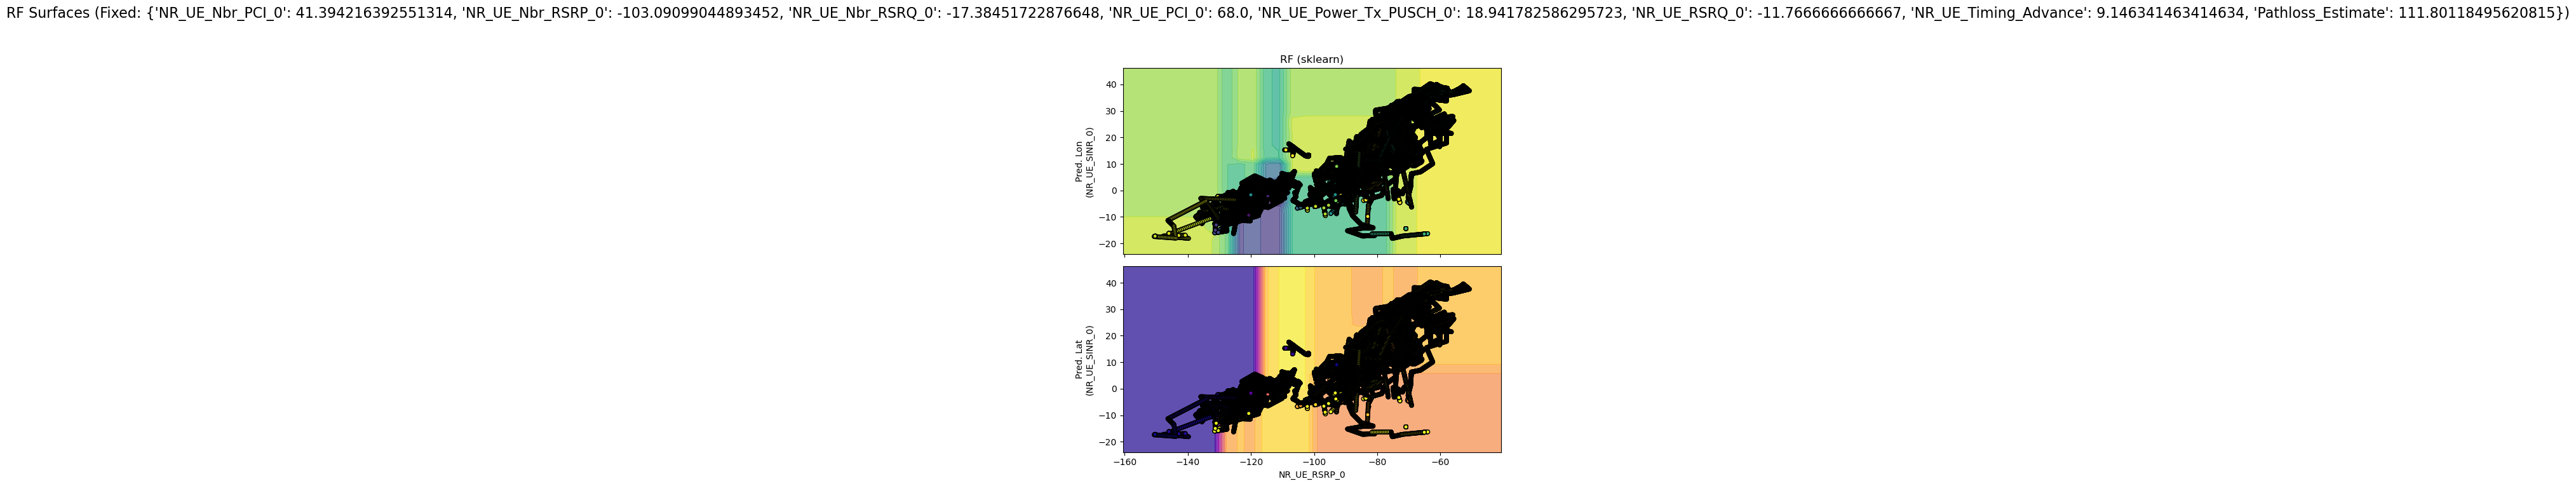

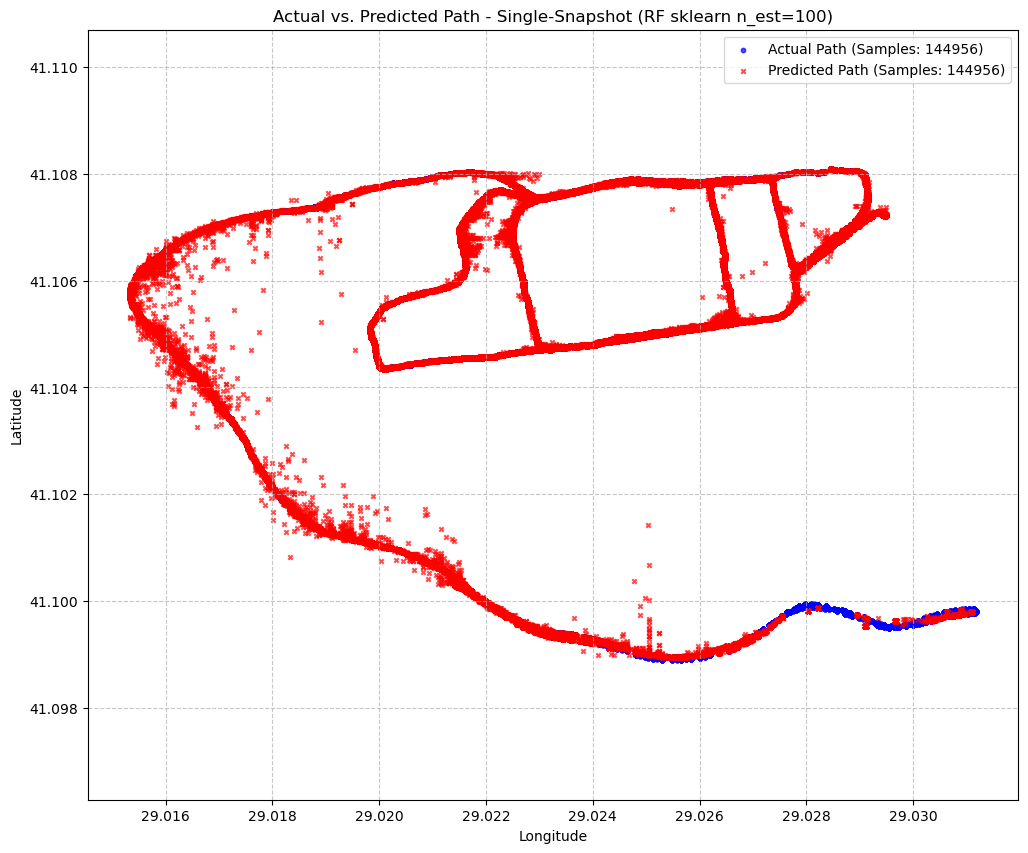


--- Evaluating Single-Snapshot (RF n_est=100, Backend: sklearn) & CDF ---


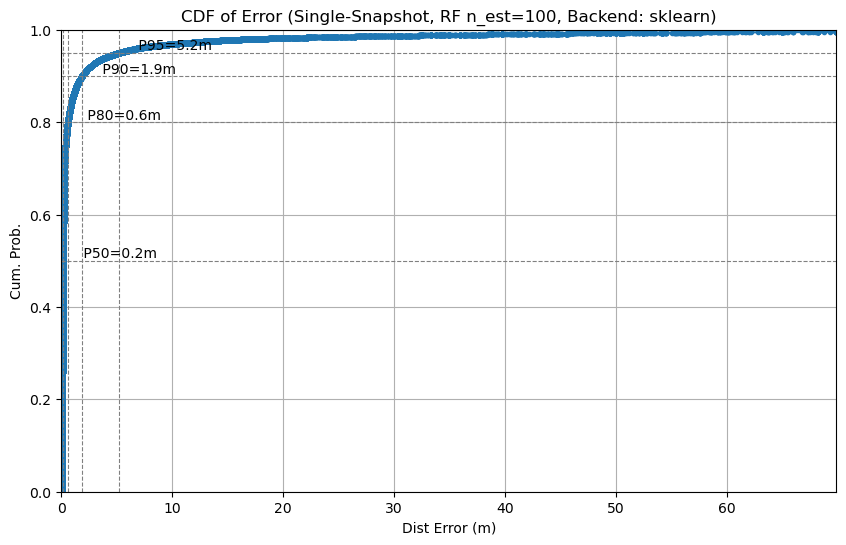

  Mean error: 1.75m, Median: 0.16m


=== PART 2: WINDOWED MVF WITH RandomForest (sklearn) ===

Creating Windowed MVF features with T=5 using 9 base radio features...
  Generated 138900 windowed MVF samples (each with 46 features).
  Model & scaler loaded:trained_models_rf_multi_file_final_v2\rf_mvf_t5_lon.joblib,trained_models_rf_multi_file_final_v2\scaler_mvf_t5.joblib
  Model & scaler loaded:trained_models_rf_multi_file_final_v2\rf_mvf_t5_lat.joblib,trained_models_rf_multi_file_final_v2\scaler_mvf_t5.joblib


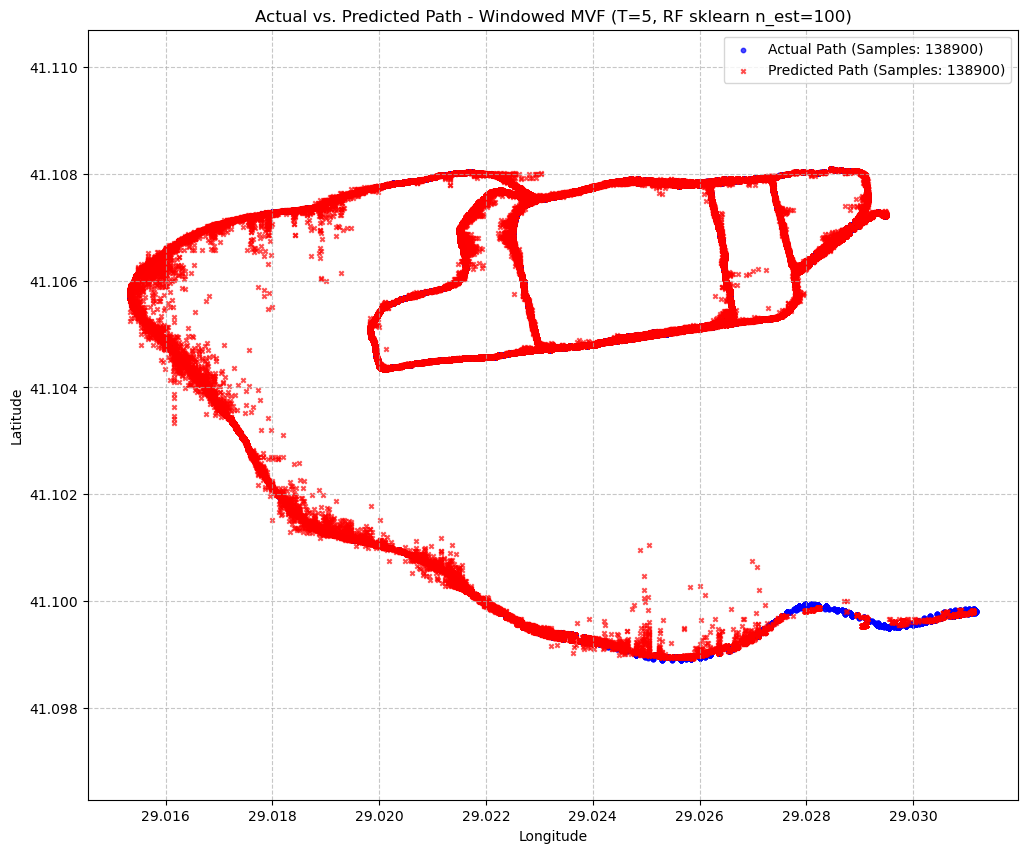


--- Evaluating Windowed MVF (T=5) (RF n_est=100, Backend: sklearn) & CDF ---


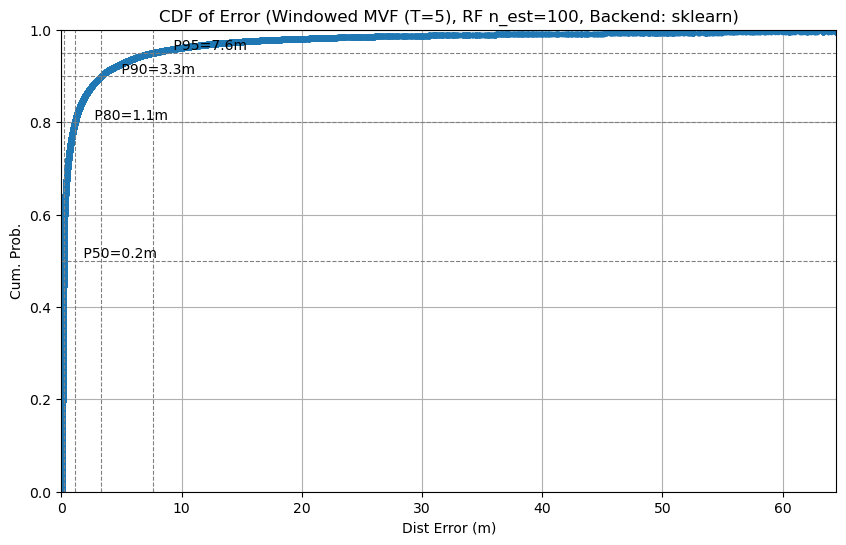

  Mean error: 2.04m, Median: 0.19m

--- Predict Location using Windowed MVF RandomForest Model (T=5) ---
Please enter values for prediction (using canonical feature names based on loaded data):


KeyboardInterrupt: Interrupted by user

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor 
from sklearn.impute import SimpleImputer
from math import radians, sin, cos, sqrt, atan2, asin
import matplotlib.pyplot as plt
import joblib
import os

# Try to import cuML RandomForestRegressor, fallback to scikit-learn
try:
    from cuml.ensemble import RandomForestRegressor as cuMLRandomForestRegressor
    import cupy
    print("cuML RandomForestRegressor found. Will attempt to use GPU.")
    RF_BACKEND_DEFAULT = "cuml"
except ImportError:
    from sklearn.ensemble import RandomForestRegressor as SklearnRandomForestRegressor
    print("cuML RandomForestRegressor not found. Using scikit-learn's RandomForestRegressor (CPU-based).")
    RF_BACKEND_DEFAULT = "sklearn"
    cupy = None

# --- Configuration ---
FILE_PATH_INPUTS = ['UL_fill.csv', 'DL_fill.csv'] 

FEATURE_MAPPING = {
    'NR_UE_PCI_0': ['NR_UE_PCI_0'],
    'NR_UE_RSRP_0': ['NR_UE_RSRP_0'],
    'NR_UE_RSRQ_0': ['NR_UE_RSRQ_0'],
    'NR_UE_SINR_0': ['NR_UE_SINR_0'],
    'Pathloss_Estimate': ['NR_UE_Pathloss_DL_0', 'NR_UE_Pathloss_UL_0'],
    'NR_UE_Nbr_RSRQ_0': ['NR_UE_Nbr_RSRQ_0'],
    'NR_UE_Nbr_RSRP_0': ['NR_UE_Nbr_RSRP_0'],
    'NR_UE_Nbr_PCI_0': ['NR_UE_Nbr_PCI_0'],
    'Modulation_Avg': ['NR_UE_Modulation_Avg_DL_0', 'NR_UE_Modulation_Avg_UL_0'],
    'NR_UE_Timing_Advance': ['NR_UE_Timing_Advance'],
    'NR_UE_Power_Tx_PUSCH_0': ['NR_UE_Power_Tx_PUSCH_0']
}
CANONICAL_FEATURE_COLS = list(FEATURE_MAPPING.keys())
TARGET_COLS_LIST = ['Longitude', 'Latitude']
PCI_COL_MVF = 'NR_UE_PCI_0' 

RF_N_ESTIMATORS = 100
RF_MAX_DEPTH = None 
RF_MIN_SAMPLES_SPLIT = 2
RF_MIN_SAMPLES_LEAF = 1
RF_RANDOM_STATE = 42
IMPUTE_STRATEGY = 'mean' 
WINDOW_SIZE_T = 5

MODEL_DIR = "trained_models_rf_multi_file_final_v2" # New directory
RF_SINGLE_MODEL_LON_PATH = os.path.join(MODEL_DIR, "rf_single_lon.joblib")
RF_SINGLE_MODEL_LAT_PATH = os.path.join(MODEL_DIR, "rf_single_lat.joblib")
RF_MVF_MODEL_LON_PATH = os.path.join(MODEL_DIR, f"rf_mvf_t{WINDOW_SIZE_T}_lon.joblib")
RF_MVF_MODEL_LAT_PATH = os.path.join(MODEL_DIR, f"rf_mvf_t{WINDOW_SIZE_T}_lat.joblib")
SCALER_SINGLE_PATH = os.path.join(MODEL_DIR, "scaler_single_snapshot.joblib")
SCALER_MVF_PATH = os.path.join(MODEL_DIR, f"scaler_mvf_t{WINDOW_SIZE_T}.joblib")

# --- Helper Function: Haversine Distance ---
def haversine(lat1,lon1,lat2,lon2):
    if any(pd.isna([lat1,lon1,lat2,lon2])): return np.nan
    lon1,lat1,lon2,lat2=map(radians,[float(lon1),float(lat1),float(lon2),float(lat2)])
    dlon,dlat=lon2-lon1,lat2-lat1;a=sin(dlat/2)**2+cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c=2*asin(sqrt(a));r=6371;return c*r*1000

# --- Load and Prepare Data Function (robust version from before) ---
def load_and_prepare_data_multi_file(filepaths_list, feature_mapping_dict, target_column_list, impute_strategy=None):
    all_cleaned_dfs = []
    canonical_feature_names = list(feature_mapping_dict.keys())
    globally_potential_canonical_features = set(canonical_feature_names)
    file_headers_cache = {} # Cache headers to avoid re-reading for column checks

    for filepath in filepaths_list:
        print(f"\nInspecting headers in {filepath} for potential features...")
        try:
            # Efficiently get headers
            with open(filepath, 'r') as f:
                header_line = f.readline().strip()
            file_header = [col.strip('"') for col in header_line.split(',')] # Handle quoted headers
            file_headers_cache[filepath] = file_header
            
            found_in_this_file = set()
            for canonical_name, source_names in feature_mapping_dict.items():
                if any(src_name in file_header for src_name in source_names):
                    found_in_this_file.add(canonical_name)
            globally_potential_canonical_features.intersection_update(found_in_this_file)
            if not found_in_this_file:
                 print(f"  Warning: No mapped features found in header of '{filepath}'.")
        except FileNotFoundError: print(f"  Error: File '{filepath}' not found."); return None,None,None,None,None
        except Exception as e: print(f"  Error reading header of '{filepath}': {e}."); return None,None,None,None,None

    if not globally_potential_canonical_features:
        print("Error: No common canonical features identified across all files."); return None,None,None,None,None
    
    final_canonical_features_to_process = sorted(list(globally_potential_canonical_features))
    print(f"\nCommon canonical features for processing: {final_canonical_features_to_process}")
    if not final_canonical_features_to_process: return None,None,None,None,None

    for filepath in filepaths_list:
        print(f"Processing {filepath} with common feature set...")
        # Determine which source columns are needed for *this file* to get the canonical features
        cols_to_read_this_file_sources = set()
        rename_map_this_file = {}
        file_header = file_headers_cache.get(filepath, []) # Get cached header

        for canonical_name in final_canonical_features_to_process:
            source_names = feature_mapping_dict.get(canonical_name, [])
            found_source_name_for_canonical = None
            for src_name in source_names:
                if src_name in file_header: # Check if source name is in this file's actual header
                    cols_to_read_this_file_sources.add(src_name)
                    if canonical_name not in rename_map_this_file.values(): # Map only the first found source
                         rename_map_this_file[src_name] = canonical_name
                    break # Found a source for this canonical name in this file
        
        # Add target columns to the list of columns to read
        cols_to_read_this_file_sources.update(target_column_list)
        
        try:
            df = pd.read_csv(filepath, low_memory=False, usecols=list(cols_to_read_this_file_sources))
        except ValueError as e: print(f"  Error reading selected columns from '{filepath}': {e}. Ensure all in usecols exist. Skipping."); continue
        except FileNotFoundError: continue

        df.rename(columns=rename_map_this_file, inplace=True)
        
        # Ensure all final_canonical_features are present, add missing ones as NaN
        for c_name in final_canonical_features_to_process:
            if c_name not in df.columns: df[c_name] = np.nan

        df_subset = df[final_canonical_features_to_process + target_column_list].copy()

        for col in final_canonical_features_to_process + target_column_list:
            if df_subset[col].dtype == 'object':
                df_subset[col] = df_subset[col].replace(['-', 'NA', 'N/A', '', ' ', 'null', 'NULL'], np.nan, regex=False)
            df_subset[col] = pd.to_numeric(df_subset[col], errors='coerce')

        df_cleaned_targets = df_subset.dropna(subset=target_column_list)
        if len(df_cleaned_targets) == 0: print(f"  No rows with valid targets in '{filepath}'."); continue
        
        X_features_this_file = df_cleaned_targets[final_canonical_features_to_process].copy()
        y_targets_this_file = df_cleaned_targets[target_column_list].copy()

        cols_all_nan_pre_impute = X_features_this_file.columns[X_features_this_file.isna().all()].tolist()
        X_processed_this_file = X_features_this_file 
        
        if impute_strategy is not None and X_features_this_file.isna().sum().sum() > 0 and not X_features_this_file.empty:
            imputable_cols = [col for col in X_features_this_file.columns if col not in cols_all_nan_pre_impute]
            if not imputable_cols: print(f"    All features in '{filepath}' are NaN. No imputation.")
            else:
                print(f"  Imputing for '{filepath}' on {len(imputable_cols)} features using '{impute_strategy}'...")
                imputer = SimpleImputer(strategy=impute_strategy)
                X_imputed_np = imputer.fit_transform(X_features_this_file[imputable_cols])
                X_processed_imputed_part = pd.DataFrame(X_imputed_np, columns=imputable_cols, index=X_features_this_file.index)
                for col in imputable_cols: X_processed_this_file[col] = X_processed_imputed_part[col]
                print(f"    NaN counts AFTER imputation for '{filepath}': {X_processed_this_file.isna().sum().sum()}")
        elif X_features_this_file.isna().sum().sum() > 0 and impute_strategy is None and not X_features_this_file.empty:
             print(f"  Dropping rows with NaN features in '{filepath}'.")
             X_processed_this_file = X_features_this_file.dropna()
             y_targets_this_file = y_targets_this_file.loc[X_processed_this_file.index] 
             if X_processed_this_file.empty: print(f"    No rows left in '{filepath}'."); continue
        
        if not X_processed_this_file.empty:
            all_cleaned_dfs.append(pd.concat([X_processed_this_file, y_targets_this_file], axis=1))
            print(f"  Added {len(X_processed_this_file)} rows from '{filepath}'.")
        else: print(f"  No usable feature rows from '{filepath}'.")

    if not all_cleaned_dfs: print("Error: No data combined."); return None,None,None,None,None
    final_df_cleaned = pd.concat(all_cleaned_dfs, ignore_index=True)
    
    # Ensure final_df_cleaned has all final_canonical_features_to_process, add if missing (as all NaN)
    for col in final_canonical_features_to_process:
        if col not in final_df_cleaned.columns:
            final_df_cleaned[col] = np.nan
            print(f"Warning: Canonical feature '{col}' was missing from all data, added as NaN column.")

    X_final_candidate = final_df_cleaned[final_canonical_features_to_process].copy()
    final_all_nan_cols = X_final_candidate.columns[X_final_candidate.isna().all()].tolist()
    
    if final_all_nan_cols:
        print(f"  Combined dataset had all-NaN columns: {final_all_nan_cols}. Dropping them globally.")
        X_final = X_final_candidate.drop(columns=final_all_nan_cols)
        actual_final_feature_list = X_final.columns.tolist()
    else:
        X_final = X_final_candidate
        actual_final_feature_list = final_canonical_features_to_process[:]

    if X_final.empty or not actual_final_feature_list:
        print("Error: Final combined feature dataset is empty or has no valid features."); return None,None,None,None,None
        
    final_df_cleaned = final_df_cleaned.dropna(subset=actual_final_feature_list)
    if final_df_cleaned.empty:
        print("Error: Final combined dataset became empty after dropping rows with NaNs."); return None,None,None,None,None

    X_final = final_df_cleaned[actual_final_feature_list]
    y_lon_final = final_df_cleaned[target_column_list[0]]
    y_lat_final = final_df_cleaned[target_column_list[1]]

    print(f"\nTotal combined usable rows: {len(final_df_cleaned)}")
    print(f"Final feature set for modeling: {actual_final_feature_list}")
    
    return X_final, y_lon_final, y_lat_final, final_df_cleaned, actual_final_feature_list

# --- Create Windowed MVF Features (same as before) ---
def create_windowed_mvf_features(df_cleaned_full, window_T, 
                                 base_radio_features_list, pci_col_name, 
                                 target_cols=['Longitude', 'Latitude']):
    # ... (Keep this function as in the previous RandomForest script) ...
    print(f"\nCreating Windowed MVF features with T={window_T} using {len(base_radio_features_list)} base radio features...")
    if df_cleaned_full.empty or len(df_cleaned_full) < window_T : print("  Not enough data for MVF."); return None,None,None,None,None
    if pci_col_name not in df_cleaned_full.columns:print(f"Error: PCI col '{pci_col_name}' not found for MVF."); return None,None,None,None,None
    missing_base_feats = [feat for feat in base_radio_features_list if feat not in df_cleaned_full.columns]
    if missing_base_feats: print(f"Error: Base radio features for MVF missing: {missing_base_feats}"); return None,None,None,None,None
    df_sorted = df_cleaned_full.sort_values(by=target_cols + (['Message'] if 'Message' in df_cleaned_full.columns else [])).reset_index(drop=True)
    windowed_data = []; new_feature_names = []
    for t in range(window_T):
        for feat in base_radio_features_list: new_feature_names.append(f"{feat}_t-{window_T-1-t}")
    new_feature_names.append(pci_col_name + "_last")
    grouped = df_sorted.groupby(target_cols, group_keys=False)
    for _, group in grouped:
        if len(group) >= window_T:
            for i in range(len(group) - window_T + 1):
                window = group.iloc[i : i + window_T]; flat_features = []
                for t_idx in range(window_T):
                    for radio_feat in base_radio_features_list: flat_features.append(window[radio_feat].iloc[t_idx])
                flat_features.append(window[pci_col_name].iloc[-1])
                windowed_data.append(flat_features + [window[target_cols[0]].iloc[-1], window[target_cols[1]].iloc[-1]])
    if not windowed_data: print("  No MVF windows created."); return None,None,None,None,None
    df_windowed = pd.DataFrame(windowed_data, columns=new_feature_names + target_cols)
    print(f"  Generated {len(df_windowed)} windowed MVF samples (each with {len(new_feature_names)} features).")
    if len(df_windowed) < 10: print(f"  Warning: Very few MVF samples ({len(df_windowed)}).");
    return df_windowed[new_feature_names], df_windowed[target_cols[0]], df_windowed[target_cols[1]], new_feature_names


# --- Train RandomForest Models (cuML or scikit-learn - same as before) ---
def train_rf_models_with_scaler(X_train_df, y_train_series, 
                                feature_scaler_save_path, current_rf_backend, model_description="RandomForest",
                                n_estimators=RF_N_ESTIMATORS, max_depth=RF_MAX_DEPTH, 
                                min_samples_split=RF_MIN_SAMPLES_SPLIT, min_samples_leaf=RF_MIN_SAMPLES_LEAF, 
                                random_state=RF_RANDOM_STATE):
    # ... (Keep this function as is) ...
    if X_train_df is None or X_train_df.empty: print(f"No training data for {model_description}."); return None, None, current_rf_backend
    feature_scaler = StandardScaler(); X_train_scaled_np = feature_scaler.fit_transform(X_train_df)
    joblib.dump(feature_scaler, feature_scaler_save_path); print(f"  Feature scaler saved: {feature_scaler_save_path}")
    X_train_scaled_np = X_train_scaled_np.astype(np.float32); y_train_np = y_train_series.values.astype(np.float32)
    print(f"  Training {model_description} (n_est={n_estimators}). Backend: {current_rf_backend}")
    rf_backend_to_use = current_rf_backend
    if rf_backend_to_use == "cuml":
        try:
            model = cuMLRandomForestRegressor(n_estimators=n_estimators,max_depth=max_depth if max_depth is not None else 16,min_samples_split=min_samples_split,min_samples_leaf=min_samples_leaf,random_state=random_state,n_streams=1)
            model.fit(X_train_scaled_np, y_train_np); print(f"    Trained with cuML RF (GPU).")
        except Exception as e:
            print(f"    Error cuML RF ({e}). Fallback to sklearn."); rf_backend_to_use = "sklearn"
            model = SklearnRandomForestRegressor(n_estimators=n_estimators,max_depth=max_depth,min_samples_split=min_samples_split,min_samples_leaf=min_samples_leaf,random_state=random_state,n_jobs=-1)
            model.fit(X_train_scaled_np, y_train_np); print(f"    Trained with sklearn RF (CPU).")
    if rf_backend_to_use == "sklearn": # Handles initial sklearn or fallback
        model = SklearnRandomForestRegressor(n_estimators=n_estimators,max_depth=max_depth,min_samples_split=min_samples_split,min_samples_leaf=min_samples_leaf,random_state=random_state,n_jobs=-1)
        model.fit(X_train_scaled_np, y_train_np); print(f"    Trained with sklearn RF (CPU).")
    return model, feature_scaler, rf_backend_to_use

# --- Save/Load Model/Scaler Functions (same) ---
def save_model_and_scaler(model,scaler,model_path,scaler_path):
    if not os.path.exists(MODEL_DIR):os.makedirs(MODEL_DIR)
    try:joblib.dump(model,model_path);joblib.dump(scaler,scaler_path);print(f"  Model saved:{model_path}, Scaler:{scaler_path}")
    except Exception as e:print(f"  Error saving:{e}")
def load_model_and_scaler(model_path,scaler_path):
    if os.path.exists(model_path) and os.path.exists(scaler_path):
        try:model=joblib.load(model_path);scaler=joblib.load(scaler_path);print(f"  Model & scaler loaded:{model_path},{scaler_path}");return model,scaler
        except Exception as e:print(f"  Error loading:{e}. Retraining.");return None,None
    return None,None

# --- Visualization, Prediction, CDF Functions ---
def plot_rf_regression_surfaces(X_data_single_snapshot, y_lon_data_single_snapshot, y_lat_data_single_snapshot,
                                 actual_feature_names_for_plot, rf_model_lon, rf_model_lat, scaler_viz,
                                 active_rf_backend, viz_feat_x_default='NR_UE_RSRP_0', viz_feat_y_default='NR_UE_SINR_0'):
    print(f"\n--- Generating RF Surface Plots (Features: {', '.join(actual_feature_names_for_plot[:2])}...) ---")
    if X_data_single_snapshot.empty or rf_model_lon is None or rf_model_lat is None or scaler_viz is None :
        print("No data/model/scaler for RF surfaces."); return

    viz_x = viz_feat_x_default
    viz_y = viz_feat_y_default

    if viz_x not in actual_feature_names_for_plot or viz_y not in actual_feature_names_for_plot:
        print(f"  Default viz features ('{viz_x}', '{viz_y}') not in available features: {actual_feature_names_for_plot}.")
        numeric_cols = [
            col for col in actual_feature_names_for_plot 
            if 'PCI' not in col and col in X_data_single_snapshot.columns and # Ensure col exists in df
               X_data_single_snapshot[col].dtype in [np.float64, np.int64, np.float32]
        ]
        if len(numeric_cols) >= 2:
            viz_x = numeric_cols[0]
            viz_y = numeric_cols[1]
            print(f"  Using fallback visualization features: '{viz_x}' and '{viz_y}'")
        else:
            print("  Not enough suitable numeric features for visualization. Skipping surface plot.")
            return
    
    if viz_x not in X_data_single_snapshot.columns or viz_y not in X_data_single_snapshot.columns:
        print(f"  Error: Chosen visualization features '{viz_x}' or '{viz_y}' are not in the provided DataFrame columns. Skipping plot.")
        return

    fixed_features_list = [f for f in actual_feature_names_for_plot if f not in [viz_x, viz_y]]
    fixed_values_dict = {} # DEFINED HERE
    for feat in fixed_features_list:
        if feat in X_data_single_snapshot.columns:
            if X_data_single_snapshot[feat].nunique(dropna=True) < 10 or "PCI" in feat: # dropna=True for nunique
                # Ensure mode() is not empty before accessing [0]
                mode_val = X_data_single_snapshot[feat].mode()
                fixed_values_dict[feat] = mode_val[0] if not mode_val.empty else X_data_single_snapshot[feat].median()
            else:
                fixed_values_dict[feat] = X_data_single_snapshot[feat].median()
        # else: # Feature for fixing is not in current data, might happen if a common feature was all NaN
              # print(f"  Warning: Feature '{feat}' intended for fixing is not in the current single snapshot data for plotting.")
              # This case should be rare if actual_feature_names_for_plot is correctly derived from X_data_single_snapshot

    print(f"Visualizing RF for '{viz_x}' & '{viz_y}'. Fixed: {fixed_values_dict}") # CORRECTED to fixed_values_dict
    
    x_min,x_max=X_data_single_snapshot[viz_x].min(),X_data_single_snapshot[viz_x].max()
    y_min,y_max=X_data_single_snapshot[viz_y].min(),X_data_single_snapshot[viz_y].max()
    xr=x_max-x_min if x_max>x_min else 1.0;yr=y_max-y_min if y_max>y_min else 1.0;plot_density=30
    xx,yy=np.meshgrid(np.linspace(x_min-0.1*xr,x_max+0.1*xr,plot_density),np.linspace(y_min-0.1*yr,y_max+0.1*yr,plot_density))
    fig,axes=plt.subplots(2,1,figsize=(7,8),sharex='col',squeeze=False);print("  Plotting RF surface...")
    grid_data_list=[]
    for rv,sv in zip(xx.ravel(),yy.ravel()):
        pt={viz_x:rv,viz_y:sv}
        pt.update(fixed_values_dict)
        current_point_features = []
        for fn_expected in actual_feature_names_for_plot: 
            current_point_features.append(pt.get(fn_expected, np.nan)) 
        grid_data_list.append(current_point_features)

    grid_df=pd.DataFrame(grid_data_list,columns=actual_feature_names_for_plot)
    # Impute NaNs in grid_df that might have arisen from pt.get if a fixed feature was missing
    if grid_df.isna().sum().sum() > 0:
        imputer_grid = SimpleImputer(strategy='mean') # Or another appropriate strategy
        grid_df_imputed_np = imputer_grid.fit_transform(grid_df)
        grid_df = pd.DataFrame(grid_df_imputed_np, columns=actual_feature_names_for_plot)

    grid_scaled=scaler_viz.transform(grid_df).astype(np.float32)
    
    Z_lon=rf_model_lon.predict(grid_scaled).reshape(xx.shape)
    Z_lat=rf_model_lat.predict(grid_scaled).reshape(xx.shape)
    
    if active_rf_backend=="cuml" and cupy: 
        Z_lon=cupy.asnumpy(Z_lon) if isinstance(Z_lon,cupy.ndarray) else Z_lon
        Z_lat=cupy.asnumpy(Z_lat) if isinstance(Z_lat,cupy.ndarray) else Z_lat
    
    ax_lon,ax_lat=axes[0,0],axes[1,0]
    ax_lon.contourf(xx,yy,Z_lon,alpha=0.7,cmap='viridis',levels=15);ax_lon.scatter(X_data_single_snapshot[viz_x],X_data_single_snapshot[viz_y],c=y_lon_data_single_snapshot,cmap='viridis',edgecolor='k',s=20,vmin=np.nanmin(Z_lon),vmax=np.nanmax(Z_lon))
    ax_lon.set_title(f'RF ({active_rf_backend})');ax_lon.set_ylabel(f'Pred. Lon\n({viz_y})')
    
    ax_lat.contourf(xx,yy,Z_lat,alpha=0.7,cmap='plasma',levels=15);ax_lat.scatter(X_data_single_snapshot[viz_x],X_data_single_snapshot[viz_y],c=y_lat_data_single_snapshot,cmap='plasma',edgecolor='k',s=20,vmin=np.nanmin(Z_lat),vmax=np.nanmax(Z_lat))
    ax_lat.set_ylabel(f'Pred. Lat\n({viz_y})');ax_lat.set_xlabel(viz_x)
    
    fig.suptitle(f"RF Surfaces (Fixed: {fixed_values_dict})",fontsize=16);plt.tight_layout(rect=[0,0.03,1,0.95]);plt.show() # CORRECTED to fixed_values_dict

def predict_location_user_windowed_rf(input_features_dict,rf_model_lon,rf_model_lat,trained_scaler,window_T,windowed_feature_names_ordered,base_radio_features_list_ordered,pci_col_name,active_rf_backend):
    # ... (This function remains the same) ...
    user_window_flat = []
    for t_step in range(window_T):
        for radio_feat_name in base_radio_features_list_ordered: 
            if radio_feat_name not in input_features_dict: print(f"Missing {radio_feat_name} in user input for MVF window."); return None,None
            user_window_flat.append(input_features_dict[radio_feat_name])
    if pci_col_name not in input_features_dict: print(f"Missing {pci_col_name} in user input for MVF window."); return None,None
    user_window_flat.append(input_features_dict[pci_col_name])
    if len(user_window_flat) != len(windowed_feature_names_ordered): print(f"User input len mismatch. Exp {len(windowed_feature_names_ordered)} got {len(user_window_flat)}"); return None,None
    user_df = pd.DataFrame([user_window_flat], columns=windowed_feature_names_ordered)
    user_scaled_np = trained_scaler.transform(user_df).astype(np.float32)
    pred_lon = rf_model_lon.predict(user_scaled_np)[0]; pred_lat = rf_model_lat.predict(user_scaled_np)[0]
    if active_rf_backend=="cuml" and cupy: pred_lon=pred_lon.item() if isinstance(pred_lon,cupy.ndarray) else pred_lon; pred_lat=pred_lat.item() if isinstance(pred_lat,cupy.ndarray) else pred_lat
    return pred_lon, pred_lat

def evaluate_and_plot_cdf_rf(X_eval_df,y_lon_actual_series,y_lat_actual_series,rf_model_lon,rf_model_lat,trained_scaler,model_type_name,active_rf_backend,rf_params_for_title=f"n_est={RF_N_ESTIMATORS}"):
    # ... (This function remains the same) ...
    print(f"\n--- Evaluating {model_type_name} (RF {rf_params_for_title}, Backend: {active_rf_backend}) & CDF ---")
    if X_eval_df is None or X_eval_df.empty: print("No data for CDF."); return
    X_eval_scaled = trained_scaler.transform(X_eval_df).astype(np.float32)
    y_lon_pred = rf_model_lon.predict(X_eval_scaled); y_lat_pred = rf_model_lat.predict(X_eval_scaled)
    if active_rf_backend=="cuml" and cupy: y_lon_pred=cupy.asnumpy(y_lon_pred) if isinstance(y_lon_pred,cupy.ndarray) else y_lon_pred; y_lat_pred=cupy.asnumpy(y_lat_pred) if isinstance(y_lat_pred,cupy.ndarray) else y_lat_pred
    distances=[];y_lon_vals=y_lon_actual_series.values;y_lat_vals=y_lat_actual_series.values
    for i in range(len(y_lon_vals)):
        dist=haversine(y_lat_vals[i],y_lon_vals[i],y_lat_pred[i],y_lon_pred[i])
        if not pd.isna(dist): distances.append(dist)
    if not distances: print("No valid distances for CDF."); return
    distances=np.array(distances);sorted_distances=np.sort(distances);cum_prob=np.arange(1,len(sorted_distances)+1)/len(sorted_distances)
    plt.figure(figsize=(10,6));plt.plot(sorted_distances,cum_prob,marker='.',linestyle='-');plt.title(f'CDF of Error ({model_type_name}, RF {rf_params_for_title}, Backend: {active_rf_backend})')
    plt.xlabel('Dist Error (m)');plt.ylabel('Cum. Prob.');plt.grid(True);xlim_max=max(10,np.percentile(sorted_distances,99.5) if len(sorted_distances)>0 else 10);plt.xlim(left=0,right=xlim_max);plt.ylim(0,1)
    percentiles=[50,80,90,95];
    for p in percentiles:
        if len(sorted_distances)>0:
            val_p=np.percentile(sorted_distances,p);plt.axhline(p/100,color='gray',ls='--',lw=0.8);plt.axvline(val_p,color='gray',ls='--',lw=0.8)
            plt.text(min(val_p+xlim_max*0.02,xlim_max*0.95),p/100,f' P{p}={val_p:.1f}m',va='bottom',ha='left')
    plt.show()
    if len(distances)>0: print(f"  Mean error: {np.nanmean(distances):.2f}m, Median: {np.nanmedian(distances):.2f}m")


def plot_actual_vs_predicted_path(lon_actual, lat_actual, lon_pred, lat_pred, title_prefix=""):
    plt.figure(figsize=(12, 10))
    plt.scatter(lon_actual, lat_actual, label=f'Actual Path (Samples: {len(lon_actual)})', s=10, c='blue', alpha=0.7)
    plt.scatter(lon_pred, lat_pred, label=f'Predicted Path (Samples: {len(lon_pred)})', s=10, c='red', marker='x', alpha=0.7)
    
    # Optionally draw lines connecting actual to predicted for a subset to show error vectors
    # This can be very cluttered if all points are drawn.
    # num_lines_to_draw = min(len(lon_actual), 100) # Draw for a subset
    # for i in range(num_lines_to_draw):
    #     plt.plot([lon_actual.iloc[i], lon_pred[i]], [lat_actual.iloc[i], lat_pred[i]], 'k--', lw=0.3, alpha=0.4)

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Actual vs. Predicted Path - {title_prefix}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axis('equal') # Important for correct aspect ratio of geo-coordinates
    plt.show()

# --- Main Execution (Modified to include the new path plot) ---
if __name__ == "__main__":
    if not os.path.exists(MODEL_DIR): os.makedirs(MODEL_DIR)

    current_active_rf_backend = RF_BACKEND_DEFAULT 

    print(f"=== PART 1: SINGLE-SNAPSHOT FINGERPRINTING WITH RandomForest ({current_active_rf_backend}) ===")
    rf_lon_s, rf_lat_s, scaler_s = None, None, None
    
    X_single, y_lon_single, y_lat_single, df_clean_single, actual_single_feat_names = \
        load_and_prepare_data_multi_file(FILE_PATH_INPUTS, FEATURE_MAPPING, TARGET_COLS_LIST, impute_strategy=IMPUTE_STRATEGY)
    
    BASE_RADIO_FEATURES_MVF_ACTUAL = [] 
    if X_single is not None and actual_single_feat_names:
        BASE_RADIO_FEATURES_MVF_ACTUAL = [col for col in actual_single_feat_names if col != PCI_COL_MVF]
        if PCI_COL_MVF not in actual_single_feat_names and PCI_COL_MVF in CANONICAL_FEATURE_COLS:
             print(f"WARNING: Canonical Primary PCI col '{PCI_COL_MVF}' not in loaded common features for single-snapshot.")
        
        loaded_lon_s, loaded_scaler_s_lon = load_model_and_scaler(RF_SINGLE_MODEL_LON_PATH, SCALER_SINGLE_PATH)
        loaded_lat_s, _                     = load_model_and_scaler(RF_SINGLE_MODEL_LAT_PATH, SCALER_SINGLE_PATH)
        if loaded_lon_s and loaded_lat_s and loaded_scaler_s_lon:
            if hasattr(loaded_scaler_s_lon,'n_features_in_') and loaded_scaler_s_lon.n_features_in_ != len(actual_single_feat_names):
                print("  Scaler feature count mismatch for single-snapshot. Retraining RF models."); rf_lon_s,rf_lat_s,scaler_s=None,None,None
            else: rf_lon_s,rf_lat_s,scaler_s=loaded_lon_s,loaded_lat_s,loaded_scaler_s_lon
        
        if rf_lon_s is None: 
            print("  Training single-snapshot RF for Longitude..."); 
            rf_lon_s,scaler_s,backend_used_lon = train_rf_models_with_scaler(X_single,y_lon_single,SCALER_SINGLE_PATH,current_active_rf_backend,"RF Lon (Single)")
            if rf_lon_s: save_model_and_scaler(rf_lon_s,scaler_s,RF_SINGLE_MODEL_LON_PATH,SCALER_SINGLE_PATH)
            print("  Training single-snapshot RF for Latitude..."); 
            rf_lat_s,scaler_s_lat,backend_used_lat = train_rf_models_with_scaler(X_single,y_lat_single,SCALER_SINGLE_PATH,current_active_rf_backend,"RF Lat (Single)")
            if rf_lat_s: save_model_and_scaler(rf_lat_s,scaler_s_lat,RF_SINGLE_MODEL_LAT_PATH,SCALER_SINGLE_PATH) # Use scaler_s_lat if it could be different
            scaler_s = scaler_s_lat # Assume scaler for lat is the one to use if re-trained for both
            if backend_used_lon == "sklearn" or backend_used_lat == "sklearn": current_active_rf_backend = "sklearn"
        
        if all(m is not None for m in [rf_lon_s,rf_lat_s,scaler_s]):
            plot_rf_regression_surfaces(X_single,y_lon_single,y_lat_single,actual_single_feat_names,rf_lon_s,rf_lat_s,scaler_s, current_active_rf_backend)
            
            # Generate predictions for the path plot
            X_single_scaled = scaler_s.transform(X_single)
            pred_lon_single_path = rf_lon_s.predict(X_single_scaled)
            pred_lat_single_path = rf_lat_s.predict(X_single_scaled)
            if RF_BACKEND_DEFAULT == "cuml" and cupy: # Use RF_BACKEND_DEFAULT as current_active_rf_backend might change inside train
                if isinstance(pred_lon_single_path, cupy.ndarray): pred_lon_single_path = cupy.asnumpy(pred_lon_single_path)
                if isinstance(pred_lat_single_path, cupy.ndarray): pred_lat_single_path = cupy.asnumpy(pred_lat_single_path)
            
            plot_actual_vs_predicted_path(y_lon_single, y_lat_single, 
                                          pd.Series(pred_lon_single_path), pd.Series(pred_lat_single_path), # Convert to series for consistent type if needed by haversine later
                                          title_prefix=f"Single-Snapshot (RF {RF_BACKEND_DEFAULT} n_est={RF_N_ESTIMATORS})")
            
            evaluate_and_plot_cdf_rf(X_single,y_lon_single,y_lat_single,rf_lon_s,rf_lat_s,scaler_s,"Single-Snapshot", current_active_rf_backend)
    else:
        print("Skipping Part 1 (Single-Snapshot) due to data loading issues or no common features found.")

    print(f"\n\n=== PART 2: WINDOWED MVF WITH RandomForest ({current_active_rf_backend}) ===")
    rf_lon_mvf,rf_lat_mvf,scaler_mvf = None,None,None
    X_mvf,y_lon_mvf,y_lat_mvf,mvf_feat_names_actual = None,None,None,None
    
    if df_clean_single is not None and not df_clean_single.empty and BASE_RADIO_FEATURES_MVF_ACTUAL:
        if PCI_COL_MVF not in df_clean_single.columns:
            print(f"Error: Canonical PCI column '{PCI_COL_MVF}' not found in cleaned single-snapshot data. Cannot create MVF windows accurately.")
        else:
            X_mvf,y_lon_mvf,y_lat_mvf,mvf_feat_names_actual = create_windowed_mvf_features(
                df_clean_single,WINDOW_SIZE_T,BASE_RADIO_FEATURES_MVF_ACTUAL,PCI_COL_MVF,TARGET_COLS_LIST
            )
    
    if X_mvf is not None and mvf_feat_names_actual: 
        loaded_lon_mvf, loaded_scaler_mvf = load_model_and_scaler(RF_MVF_MODEL_LON_PATH, SCALER_MVF_PATH)
        loaded_lat_mvf, _                 = load_model_and_scaler(RF_MVF_MODEL_LAT_PATH, SCALER_MVF_PATH)
        if loaded_lon_mvf and loaded_lat_mvf and loaded_scaler_mvf:
            if hasattr(loaded_scaler_mvf,'n_features_in_') and loaded_scaler_mvf.n_features_in_ != len(mvf_feat_names_actual):
                print("  Scaler feature count mismatch for MVF. Retraining MVF RF."); rf_lon_mvf=None
            else: rf_lon_mvf,rf_lat_mvf,scaler_mvf = loaded_lon_mvf,loaded_lat_mvf,loaded_scaler_mvf
        
        if rf_lon_mvf is None:
            print("  Training windowed MVF RF for Longitude..."); 
            rf_lon_mvf,scaler_mvf,backend_used_lon_mvf = train_rf_models_with_scaler(X_mvf,y_lon_mvf,SCALER_MVF_PATH,current_active_rf_backend,"RF Lon (MVF)")
            if rf_lon_mvf: save_model_and_scaler(rf_lon_mvf,scaler_mvf,RF_MVF_MODEL_LON_PATH,SCALER_MVF_PATH)
            print("  Training windowed MVF RF for Latitude..."); 
            rf_lat_mvf,scaler_mvf,backend_used_lat_mvf = train_rf_models_with_scaler(X_mvf,y_lat_mvf,SCALER_MVF_PATH,current_active_rf_backend,"RF Lat (MVF)")
            if rf_lat_mvf: save_model_and_scaler(rf_lat_mvf,scaler_mvf,RF_MVF_MODEL_LAT_PATH,SCALER_MVF_PATH)
            if backend_used_lon_mvf == "sklearn" or backend_used_lat_mvf == "sklearn": current_active_rf_backend = "sklearn"
        
        if all(m is not None for m in [rf_lon_mvf,rf_lat_mvf,scaler_mvf]):
            # Generate predictions for MVF path plot
            X_mvf_scaled = scaler_mvf.transform(X_mvf)
            pred_lon_mvf_path = rf_lon_mvf.predict(X_mvf_scaled)
            pred_lat_mvf_path = rf_lat_mvf.predict(X_mvf_scaled)
            if RF_BACKEND_DEFAULT == "cuml" and cupy: # Use RF_BACKEND_DEFAULT here
                if isinstance(pred_lon_mvf_path, cupy.ndarray): pred_lon_mvf_path = cupy.asnumpy(pred_lon_mvf_path)
                if isinstance(pred_lat_mvf_path, cupy.ndarray): pred_lat_mvf_path = cupy.asnumpy(pred_lat_mvf_path)

            plot_actual_vs_predicted_path(y_lon_mvf, y_lat_mvf, 
                                          pd.Series(pred_lon_mvf_path), pd.Series(pred_lat_mvf_path),
                                          title_prefix=f"Windowed MVF (T={WINDOW_SIZE_T}, RF {RF_BACKEND_DEFAULT} n_est={RF_N_ESTIMATORS})")
            
            evaluate_and_plot_cdf_rf(X_mvf,y_lon_mvf,y_lat_mvf,rf_lon_mvf,rf_lat_mvf,scaler_mvf,f"Windowed MVF (T={WINDOW_SIZE_T})", current_active_rf_backend)
            
            print(f"\n--- Predict Location using Windowed MVF RandomForest Model (T={WINDOW_SIZE_T}) ---")
            user_input_vals = {}
            print("Please enter values for prediction (using canonical feature names based on loaded data):")
            prompt_features = actual_single_feat_names if X_single is not None and actual_single_feat_names else CANONICAL_FEATURE_COLS
            for feat_name in prompt_features:
                 while True:
                    try:
                        example_val = df_clean_single[feat_name].median() if df_clean_single is not None and not df_clean_single.empty and feat_name in df_clean_single.columns else "e.g., 0"
                        ex_str = f"{example_val:.1f}" if isinstance(example_val,(float,np.floating)) else str(example_val)
                        user_input_vals[feat_name] = float(input(f"Enter {feat_name} (e.g., {ex_str}): "))
                        break
                    except ValueError: print("Invalid input.")
                    except KeyError: print(f"  Feature '{feat_name}' not in loaded data for median. Enter manually."); user_input_vals[feat_name]=float(input(f"Enter {feat_name}: "));break
                    except Exception as e: print(f"Input error for {feat_name}:{e}"); user_input_vals[feat_name]=float(input(f"Enter {feat_name}: "));break
            
            # Ensure BASE_RADIO_FEATURES_MVF_ACTUAL is defined correctly for predict_location_user_windowed_rf
            if BASE_RADIO_FEATURES_MVF_ACTUAL and mvf_feat_names_actual :
                pred_lon,pred_lat = predict_location_user_windowed_rf(user_input_vals,rf_lon_mvf,rf_lat_mvf,scaler_mvf,WINDOW_SIZE_T,mvf_feat_names_actual,BASE_RADIO_FEATURES_MVF_ACTUAL,PCI_COL_MVF, current_active_rf_backend)
                if pred_lon is not None: print(f"\nPredicted Location (Windowed MVF RF, T={WINDOW_SIZE_T}):\n  Lon:{pred_lon:.6f}, Lat:{pred_lat:.6f}")
            else:
                print("Could not make MVF user prediction: BASE_RADIO_FEATURES_MVF_ACTUAL or mvf_feat_names_actual is not properly defined.")
    else:
        print("Skipping Part 2 (Windowed MVF) due to issues in data or MVF feature creation.")

    if (X_single is None or not actual_single_feat_names) and \
       (X_mvf is None or not BASE_RADIO_FEATURES_MVF_ACTUAL):
         print("\nNo data was successfully loaded or processed for either single-snapshot or MVF modeling. Exiting.")